# Phase 2 — Siamese KNN Clustering

**Pipeline:**
1. Load precomputed CLIP image (768d) + text (512d) embeddings
2. Load preprocessing pipeline → build `LightweightItemDataset` (price, geo, colors, depts)
3. Load trained `SiameseNetwork` from `siamese_best.pth`
4. Batched cosine KNN (block matmul, top-K=20) for candidate recall
5. Siamese re-scoring of all candidate edges → duplicate probability
6. Threshold sweep on `items_train` subsample → pick best Siamese threshold
7. `scipy.sparse.csgraph.connected_components` → cluster IDs (max 100 per cluster)
8. Write `submission_phase2.csv`


In [1]:
import sys, os, pickle, random
sys.path.insert(0, '/Users/matouskovar/FIT/adm-sp/src')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from collections import defaultdict
from tqdm import tqdm

NOTEBOOK_DIR = '/Users/matouskovar/FIT/adm-sp/src'
DATA_DIR     = '/Users/matouskovar/FIT/adm-sp/data'
PIPELINES_DIR = '/Users/matouskovar/FIT/adm-sp/artifacts/pipelines'

TEXT_EMB_DIM = 512   # CLIP text projection output dim

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: mps


## 1. Load embeddings

In [2]:
print('Loading CLIP image embeddings...')
clip_emb_dict = torch.load(f'{NOTEBOOK_DIR}/../artifacts/embeddings/clip_image.pt', map_location='cpu', weights_only=False)
print(f'  Image embeddings: {len(clip_emb_dict):,} items, dim={next(iter(clip_emb_dict.values())).shape[0]}')

print('Loading text embeddings...')
text_emb_dict = torch.load(f'{NOTEBOOK_DIR}/../artifacts/embeddings/text_multilingual.pt', map_location='cpu', weights_only=False)
print(f'  Text embeddings:  {len(text_emb_dict):,} items, dim={next(iter(text_emb_dict.values())).shape[0]}')

Loading CLIP image embeddings...
  Image embeddings: 1,128,069 items, dim=768
Loading text embeddings...
  Text embeddings:  1,325,906 items, dim=512


## 2. Load pipeline, vocab & define LightweightItemDataset


In [3]:
# Load preprocessing pipeline (fitted on items_train)
pipeline = pickle.load(open(os.path.join(PIPELINES_DIR, 'preprocessing.pkl'), 'rb'))
print('Pipeline loaded.')

# Load vocabulary
from GlamiDatasetVocabulary import GlamiVocabularyManager
vocab_manager = GlamiVocabularyManager.load_from_dir(os.path.join(NOTEBOOK_DIR, '../artifacts/vocabularies'))
print(f'Vocab — geo: {len(vocab_manager.geo_dict)}, colors: {len(vocab_manager.color_dict)}, depts: {len(vocab_manager.dept_dict)}')

def preprocess_df(df_raw, pipeline):
    """Run raw items DataFrame through the saved pipeline. Returns transformed df."""
    X = df_raw.drop(columns=['label'], errors='ignore')
    df_t = pipeline.transform(X)
    df_t['itemId'] = df_raw['itemId'].values
    return df_t


Pipeline loaded.
Vocab — geo: 13, colors: 94, depts: 3


In [4]:
class LightweightItemDataset(Dataset):
    def __init__(self, df, vocab_manager, image_embeddings_dict, text_embeddings_dict):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab_manager
        self.image_embeddings_dict = image_embeddings_dict
        self.text_embeddings_dict = text_embeddings_dict
        self.id_to_idx = {str(row['itemId']): i for i, row in self.df.iterrows()}

    def __len__(self):
        return len(self.df)

    def _to_multi_hot(self, ids_string, vocab_dict):
        tensor = torch.zeros(len(vocab_dict), dtype=torch.float32)
        if pd.isna(ids_string) or str(ids_string).strip() == '':
            return tensor
        for raw_id in str(ids_string).split(','):
            raw_id = raw_id.strip()
            if raw_id in vocab_dict:
                tensor[vocab_dict[raw_id]] = 1.0
        return tensor

    def get_item_by_id(self, item_id):
        idx = self.id_to_idx.get(str(item_id))
        return self[idx] if idx is not None else None

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        item_id = str(row['itemId'])

        price = torch.tensor([row['price_scaled']], dtype=torch.float32)
        geo   = torch.tensor(self.vocab.geo_dict.get(str(row['geo']), 0), dtype=torch.long)
        colors = self._to_multi_hot(row.get('colorTagIdsString', ''), self.vocab.color_dict)
        depts  = self._to_multi_hot(row.get('departmentIds', ''),      self.vocab.dept_dict)

        img_emb = self.image_embeddings_dict.get(item_id, torch.zeros(768, dtype=torch.float32))
        txt_emb = self.text_embeddings_dict.get(item_id,  torch.zeros(TEXT_EMB_DIM, dtype=torch.float32))
        if img_emb.device.type != 'cpu': img_emb = img_emb.cpu()
        if txt_emb.device.type != 'cpu': txt_emb = txt_emb.cpu()

        img_emb = F.normalize(img_emb, dim=0)
        txt_emb = F.normalize(txt_emb, dim=0)

        return {
            'item_id':         item_id,
            'price':           price,
            'geo':             geo,
            'colors':          colors,
            'departments':     depts,
            'image_embedding': img_emb,
            'text_embedding':  txt_emb,
        }

print('LightweightItemDataset defined.')


LightweightItemDataset defined.


In [5]:
class SiameseEmbedder(nn.Module):
    def __init__(self, hidden_dim=256, output_dim=128):
        super().__init__()
        self.image_proj = nn.Sequential(
            nn.Linear(768, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(0.2))
        self.text_proj = nn.Sequential(
            nn.Linear(TEXT_EMB_DIM, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(0.2))
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim))

    def forward(self, image_emb, text_emb, price):
        return self.fusion(torch.cat([self.image_proj(image_emb), self.text_proj(text_emb), price], dim=1))


class SiameseNetwork(nn.Module):
    def __init__(self, n_colors, n_depts, n_geos, output_dim=128):
        super().__init__()
        self.embedder = SiameseEmbedder(output_dim=output_dim)
        self.classifier = nn.Sequential(
            nn.Linear(output_dim + 5, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1))

    def forward_one(self, item):
        return self.embedder(item['image_embedding'], item['text_embedding'], item['price'])

    @staticmethod
    def _cosine_sim(a, b): return (a * b).sum(dim=1, keepdim=True)

    @staticmethod
    def _jaccard(a, b):
        inter = (a * b).sum(dim=1)
        union = (a + b).clamp(max=1.0).sum(dim=1)
        return (inter / union.clamp(min=1e-6)).unsqueeze(1)

    @staticmethod
    def _geo_match(g1, g2): return (g1 == g2).float().unsqueeze(1)

    def forward(self, item1, item2):
        emb1, emb2 = self.forward_one(item1), self.forward_one(item2)
        combined = torch.cat([
            torch.abs(emb1 - emb2),
            self._cosine_sim(item1['image_embedding'], item2['image_embedding']),
            self._cosine_sim(item1['text_embedding'],  item2['text_embedding']),
            self._jaccard(item1['departments'], item2['departments']),
            self._jaccard(item1['colors'],      item2['colors']),
            self._geo_match(item1['geo'],        item2['geo']),
        ], dim=1)
        return self.classifier(combined).squeeze(1)

# Load trained weights
n_colors = len(vocab_manager.color_dict)
n_depts  = len(vocab_manager.dept_dict)
n_geos   = len(vocab_manager.geo_dict)

siamese_model = SiameseNetwork(n_colors, n_depts, n_geos, output_dim=128).to(device)
siamese_model.load_state_dict(
    torch.load(os.path.join(NOTEBOOK_DIR, '../artifacts/models/siamese_baseline.pth'), map_location=device, weights_only=True))
siamese_model.eval()
print('SiameseNetwork loaded from siamese_best.pth')


SiameseNetwork loaded from siamese_best.pth


In [6]:
def score_edges_siamese(edge_rows, edge_cols, item_dataset, model, device,
                        batch_size=1024):
    model.eval()

    def _stack(items, key):
        t = torch.stack([it[key] for it in items])
        return t.to(device)

    scores = []
    N_edges = len(edge_rows)

    for start in tqdm(range(0, N_edges, batch_size), desc='Siamese re-scoring'):
        end = min(start + batch_size, N_edges)
        idx_i = edge_rows[start:end]
        idx_j = edge_cols[start:end]

        feats_i = [item_dataset[int(i)] for i in idx_i]
        feats_j = [item_dataset[int(j)] for j in idx_j]

        keys = ['image_embedding', 'text_embedding', 'price', 'geo', 'colors', 'departments']
        batch_i = {k: _stack(feats_i, k) for k in keys}
        batch_j = {k: _stack(feats_j, k) for k in keys}

        with torch.no_grad():
            logits = model(batch_i, batch_j)          # (B,)
            probs  = torch.sigmoid(logits).cpu().numpy()

        scores.append(probs)

    return np.concatenate(scores)

print('score_edges_siamese() defined.')


score_edges_siamese() defined.


## 2. Build embedding matrix for a given set of item IDs

In [7]:
def build_embedding_matrix(item_ids, clip_dict, text_dict, img_dim=768, txt_dim=512):
    img_zero = torch.zeros(img_dim)
    txt_zero = torch.zeros(txt_dim)

    rows = []
    for iid in item_ids:
        iid_s = str(iid)
        img = clip_dict.get(iid_s, img_zero)
        txt = text_dict.get(iid_s, txt_zero)
        rows.append(torch.cat([img, txt]))

    mat = torch.stack(rows)          # (N, 1280)
    norms = mat.norm(dim=1, keepdim=True).clamp(min=1e-8)
    mat = mat / norms                # L2-normalise
    return mat

print('build_embedding_matrix() defined.')

build_embedding_matrix() defined.


## 3. Batched cosine KNN (MPS-friendly)

In [8]:
def batched_cosine_knn(mat, top_k=20, block_size=512, sim_threshold=0.85,
                        mutual=True, device=device):
    N = mat.shape[0]
    mat_dev = mat.to(device)

    # Store top_k neighbours for each row: shape (N, top_k)
    top_indices  = torch.full((N, top_k), -1, dtype=torch.long)
    top_scores   = torch.full((N, top_k), -2.0)

    print(f'  KNN: N={N:,}, K={top_k}, block={block_size}, threshold={sim_threshold}, mutual={mutual}')

    for start in range(0, N, block_size):
        end   = min(start + block_size, N)
        block = mat_dev[start:end]                    # (B, D)
        sims  = torch.mm(block, mat_dev.T)            # (B, N)  — cosine since L2-normed

        # Mask self-similarity
        for bi in range(end - start):
            sims[bi, start + bi] = -2.0

        # top_k
        vals, idxs = torch.topk(sims, k=top_k, dim=1)   # (B, K)
        top_indices[start:end] = idxs.cpu()
        top_scores[start:end]  = vals.cpu()

        if (start // block_size) % 10 == 0:
            print(f'    block {start:>6}/{N}', end='\r')

    print(f'    KNN pass done.           ')

    # Build edge set
    if mutual:
        # neighbour set as frozenset for bidirectional check
        nbr_sets = [set(top_indices[i].tolist()) for i in range(N)]

    edge_rows, edge_cols = [], []
    for i in range(N):
        for ki in range(top_k):
            j   = top_indices[i, ki].item()
            sim = top_scores[i, ki].item()
            if j < 0 or sim < sim_threshold:
                continue
            if mutual and (i not in nbr_sets[j]):
                continue
            if i < j:   # store each edge once
                edge_rows.append(i)
                edge_cols.append(j)

    print(f'  Edges after filtering: {len(edge_rows):,}')
    return np.array(edge_rows, dtype=np.int32), np.array(edge_cols, dtype=np.int32)

print('batched_cosine_knn() defined.')

batched_cosine_knn() defined.


## 4. Cluster via connected components

In [9]:
def edges_to_clusters(edge_rows, edge_cols, n_items, item_ids):
    """
    Build sparse adjacency, run connected components, return dict {item_id: cluster_id}.
    """
    if len(edge_rows) == 0:
        # no edges → every item its own cluster
        return {iid: i for i, iid in enumerate(item_ids)}

    data = np.ones(len(edge_rows), dtype=np.int8)
    # Symmetric
    rows = np.concatenate([edge_rows, edge_cols])
    cols = np.concatenate([edge_cols, edge_rows])
    data = np.concatenate([data, data])

    adj = csr_matrix((data, (rows, cols)), shape=(n_items, n_items))
    n_components, labels = connected_components(adj, directed=False)
    print(f'  Connected components: {n_components:,} clusters from {n_items:,} items')

    id_to_cluster = {str(item_ids[i]): int(labels[i]) for i in range(n_items)}
    return id_to_cluster

print('edges_to_clusters() defined.')

edges_to_clusters() defined.


## 5. Pairwise F1 evaluation helper

In [10]:
def evaluate_phase2(id_to_cluster, id_to_label):
    """
    Pairwise F1 via C(n,2) counting — O(items), never enumerates pairs.
    Identical result to set-intersection but handles giant clusters instantly.

    Proof:
      total_pred_pairs = sum C(|pred_cluster|, 2)
      total_true_pairs = sum C(|true_label|, 2)
      TP = sum C(|pred_cluster ∩ true_label|, 2)   [composite key groups]
      FP = total_pred_pairs - TP
      FN = total_true_pairs - TP
    """
    common_ids    = list(set(id_to_cluster) & set(id_to_label))
    true_lbl_arr  = np.array([id_to_label[iid]   for iid in common_ids])
    pred_clus_arr = np.array([id_to_cluster[iid]  for iid in common_ids])

    def _c2(arr):
        _, counts = np.unique(arr, return_counts=True)
        return int((counts * (counts - 1) // 2).sum()), int(counts.max())

    total_true_pairs, _          = _c2(true_lbl_arr)
    total_pred_pairs, max_pred_sz = _c2(pred_clus_arr)

    # TP: items sharing both same true label AND same predicted cluster
    composite = np.array([f'{t}|{p}' for t, p in zip(true_lbl_arr, pred_clus_arr)])
    tp, _ = _c2(composite)

    fp = total_pred_pairs - tp
    fn = total_true_pairs - tp

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    warn = f'  ⚠️  max cluster={max_pred_sz:,} items (over-merging!)' if max_pred_sz > 300 else ''
    print(f'  n={len(common_ids):,}  max_cluster={max_pred_sz:,}  '
          f'TP={tp:,}  FP={fp:,}  FN={fn:,}  '
          f'P={precision:.4f}  R={recall:.4f}  F1={f1:.4f}{warn}')
    return {'precision': precision, 'recall': recall, 'f1': f1,
            'tp': tp, 'fp': fp, 'fn': fn, 'max_cluster': max_pred_sz}

print('evaluate_phase2() defined  (O(n) C(n,2) counting — no pair enumeration).')


evaluate_phase2() defined  (O(n) C(n,2) counting — no pair enumeration).


## 6. Val set from `val_pairs_improved.csv`

Uses the **same label-level 80/20 split** as `train_and_predict.ipynb` — val items never appear in training pairs, and negatives include hard near-duplicates mined during training.


In [11]:
print('Loading items_train...')
df_train = pd.read_csv(f'{DATA_DIR}/items_train.csv')
df_train['itemId'] = df_train['itemId'].astype(str)
print(f'  Shape: {df_train.shape}')

# Label lookup for all train items
train_label_lookup = dict(zip(df_train['itemId'], df_train['label']))

# Preprocess entire train set once (needed for LightweightItemDataset)
df_train_proc = preprocess_df(df_train, pipeline)
print('  Preprocessed.')


Loading items_train...
  Shape: (928234, 9)
  Preprocessed.


In [12]:
# ── Identify val labels from val_pairs_improved.csv ──────────────────────────
VAL_TOTAL = 30_000   # cap total val items for speed

print('Identifying val labels from val_pairs_improved.csv...')
val_pairs_df = pd.read_csv(f'{NOTEBOOK_DIR}/../artifacts/pairs/val_pairs.csv')
pos_val = val_pairs_df[val_pairs_df['is_duplicate'] == 1.0]

# Look up labels for items in positive val pairs
pos_item_ids  = set(pos_val['item_id_1'].astype(str)) | set(pos_val['item_id_2'].astype(str))
val_label_set = {train_label_lookup[iid] for iid in pos_item_ids if iid in train_label_lookup}
print(f'  Val labels identified: {len(val_label_set):,}')

# All items in items_train whose label is in the val split
df_val_dup_items = df_train[df_train['label'].isin(val_label_set)].copy()

# Cap dup items to half of VAL_TOTAL; fill the rest with noise
n_dup   = min(len(df_val_dup_items), VAL_TOTAL // 2)
n_noise = VAL_TOTAL - n_dup
df_val_dup_sample = df_val_dup_items.sample(n=n_dup, random_state=42)

df_train_non_val = df_train[~df_train['label'].isin(val_label_set)]
n_noise = min(len(df_train_non_val), n_noise)
df_val_noise = df_train_non_val.sample(n=n_noise, random_state=42)

df_val_all  = pd.concat([df_val_dup_sample, df_val_noise], ignore_index=True)
val_ids_set = set(df_val_all['itemId'].astype(str))
val_labels  = dict(zip(df_val_all['itemId'].astype(str), df_val_all['label']))

print(f'  Val items: {len(df_val_all):,}  (dup-label: {n_dup:,}  noise: {n_noise:,})')


Identifying val labels from val_pairs_improved.csv...
  Val labels identified: 6,696
  Val items: 30,000  (dup-label: 15,000  noise: 15,000)


In [13]:
# Build LightweightItemDataset and embedding matrix for the full val item set
df_val_proc = df_train_proc[df_train_proc['itemId'].isin(val_ids_set)].reset_index(drop=True)
val_item_dataset = LightweightItemDataset(
    df_val_proc, vocab_manager,
    image_embeddings_dict=clip_emb_dict,
    text_embeddings_dict=text_emb_dict
)
N = len(val_item_dataset)
val_ids = [val_item_dataset.df.iloc[i]['itemId'] for i in range(N)]
print(f'Val item dataset: {N:,} items')

print('Building val embedding matrix...')
val_mat = build_embedding_matrix(val_ids, clip_emb_dict, text_emb_dict)
print(f'  Matrix shape: {val_mat.shape}')


Val item dataset: 30,000 items
Building val embedding matrix...
  Matrix shape: torch.Size([30000, 1280])


In [14]:
# ── Cosine KNN — identical to the real phase-2 submission pipeline ────────────
KNN_COSINE_THRESHOLD = 0.60
TOP_K  = 40
MUTUAL = False
BLOCK  = 1024

print(f'=== Cosine KNN  (threshold={KNN_COSINE_THRESHOLD}, K={TOP_K}) ===')
val_mat_dev = val_mat.to(device)
all_i, all_j = [], []

for start in range(0, N, BLOCK):
    end   = min(start + BLOCK, N)
    block = val_mat_dev[start:end]
    sims  = torch.mm(block, val_mat_dev.T)
    for bi in range(end - start):
        sims[bi, start + bi] = -2.0
    vals_k, idxs = torch.topk(sims, k=TOP_K, dim=1)
    for bi in range(end - start):
        gi = start + bi
        for ki in range(TOP_K):
            gj  = idxs[bi, ki].item()
            sim = vals_k[bi, ki].item()
            if sim >= KNN_COSINE_THRESHOLD and gj > gi:
                all_i.append(gi)
                all_j.append(gj)
    if (start // BLOCK) % 20 == 0:
        print(f'  {start:>6}/{N}', end='\r')

all_i = np.array(all_i, dtype=np.int32)
all_j = np.array(all_j, dtype=np.int32)
print(f'\n  Candidate edges (cosine >= {KNN_COSINE_THRESHOLD}): {len(all_i):,}')


=== Cosine KNN  (threshold=0.6, K=40) ===
   20480/30000
  Candidate edges (cosine >= 0.6): 594,024


In [15]:
# ── Pre-cache all val item features as stacked tensors (one-time cost) ────────
# This avoids 1.2M individual __getitem__ calls during siamese scoring.
print('Pre-caching val item features...')
_keys = ['image_embedding', 'text_embedding', 'price', 'geo', 'colors', 'departments']
_cache = {k: [] for k in _keys}
for i in range(N):
    it = val_item_dataset[i]
    for k in _keys:
        _cache[k].append(it[k])
val_cache = {k: torch.stack(v) for k, v in _cache.items()}  # each: (N, D)
print(f'  Cached {N:,} items — keys: {list(val_cache.keys())}')

# ── Fast siamese scoring using pre-cached tensors ─────────────────────────────
def score_edges_fast(edge_rows, edge_cols, cache, model, device, batch_size=4096):
    model.eval()
    scores = []
    N_edges = len(edge_rows)
    for start in tqdm(range(0, N_edges, batch_size), desc='Siamese scoring (cached)'):
        end   = min(start + batch_size, N_edges)
        idx_i = edge_rows[start:end]
        idx_j = edge_cols[start:end]
        bi = {k: cache[k][idx_i].to(device) for k in cache}
        bj = {k: cache[k][idx_j].to(device) for k in cache}
        with torch.no_grad():
            logits = model(bi, bj)
            probs  = torch.sigmoid(logits).cpu().numpy()
        scores.append(probs)
    return np.concatenate(scores)

print('Siamese re-scoring (cached)...')
siamese_scores_val = score_edges_fast(all_i, all_j, val_cache, siamese_model, device, batch_size=4096)
print(f'Scored {len(siamese_scores_val):,} edges.')
print(f'Score range: [{siamese_scores_val.min():.3f}, {siamese_scores_val.max():.3f}]')


Pre-caching val item features...
  Cached 30,000 items — keys: ['image_embedding', 'text_embedding', 'price', 'geo', 'colors', 'departments']
Siamese re-scoring (cached)...


Siamese scoring (cached): 100%|██████████| 146/146 [00:03<00:00, 46.95it/s]

Scored 594,024 edges.
Score range: [0.000, 0.999]


=== Siamese Threshold Sweep ===
  Total candidate edges to sweep over: 594,024

Score percentiles:
  p  0: 0.0000
  p  1: 0.0000
  p  5: 0.0000
  p 10: 0.0000
  p 25: 0.0003
  p 50: 0.0020
  p 75: 0.0143
  p 90: 0.1422
  p 95: 0.5790
  p 99: 0.9975
  p100: 0.9992

Pre-sweep edge counts:
  θ≥0.50:   32,774 edges
  θ≥0.70:   25,666 edges
  θ≥0.80:   22,405 edges
  θ≥0.90:   19,064 edges
  θ≥0.95:   17,010 edges
  θ≥0.97:   15,980 edges
  θ≥0.98:   15,210 edges
  θ≥0.99:   13,691 edges


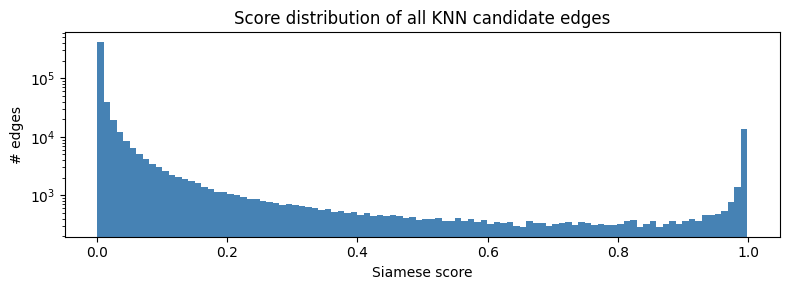


Running sweep (high→low):
  Connected components: 21,614 clusters from 30,000 items
  n=30,000  max_cluster=18  TP=14,939  FP=332  FN=7,242  P=0.9783  R=0.6735  F1=0.7978
  θ=0.99  edges= 13,691  P=0.978  R=0.674  F1=0.7978  max_cluster=18
  Connected components: 21,085 clusters from 30,000 items
  n=30,000  max_cluster=19  TP=15,884  FP=607  FN=6,297  P=0.9632  R=0.7161  F1=0.8215
  θ=0.98  edges= 15,210  P=0.963  R=0.716  F1=0.8215  max_cluster=19
  Connected components: 20,786 clusters from 30,000 items
  n=30,000  max_cluster=22  TP=16,351  FP=1,137  FN=5,830  P=0.9350  R=0.7372  F1=0.8244
  θ=0.97  edges= 15,980  P=0.935  R=0.737  F1=0.8244  max_cluster=22
  Connected components: 20,315 clusters from 30,000 items
  n=30,000  max_cluster=46  TP=16,839  FP=4,026  FN=5,342  P=0.8070  R=0.7592  F1=0.7824
  θ=0.95  edges= 17,010  P=0.807  R=0.759  F1=0.7824  max_cluster=46
  Connected components: 19,663 clusters from 30,000 items
  n=30,000  max_cluster=123  TP=17,403  FP=17,766  FN=4

In [16]:
# Threshold sweep — fast because scores are already computed, only CC + F1 evaluation remains
# Sweep descends from high→low so results print immediately even if low thresholds create huge clusters.
SWEEP_THRESHOLDS = [0.99, 0.98, 0.97, 0.95, 0.92, 0.90, 0.88, 0.85, 0.80]
sweep_results = []

import matplotlib
import matplotlib.pyplot as plt

print('=== Siamese Threshold Sweep ===')
print(f'  Total candidate edges to sweep over: {len(all_i):,}')

# Print score percentiles first to understand distribution
percentiles = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]
pvals = np.percentile(siamese_scores_val, percentiles)
print('\nScore percentiles:')
for p, v in zip(percentiles, pvals):
    print(f'  p{p:>3d}: {v:.4f}')

# Per-threshold edge counts (instant — no CC needed)
print('\nPre-sweep edge counts:')
for thr in [0.50, 0.70, 0.80, 0.90, 0.95, 0.97, 0.98, 0.99]:
    n = int((siamese_scores_val >= thr).sum())
    print(f'  θ≥{thr:.2f}: {n:>8,} edges')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(siamese_scores_val, bins=100, color='steelblue', edgecolor='none')
ax.set_xlabel('Siamese score'); ax.set_ylabel('# edges')
ax.set_title('Score distribution of all KNN candidate edges')
ax.set_yscale('log')
plt.tight_layout(); plt.show()

print('\nRunning sweep (high→low):')
for thr in SWEEP_THRESHOLDS:
    mask    = siamese_scores_val >= thr
    er, ec  = all_i[mask], all_j[mask]
    n_edges = int(mask.sum())
    id2c    = edges_to_clusters(er, ec, N, val_ids)
    res     = evaluate_phase2(id2c, val_labels)
    sweep_results.append({'threshold': thr, 'edges': n_edges, **res})
    print(f'  θ={thr:.2f}  edges={n_edges:>7,}  P={res["precision"]:.3f}  R={res["recall"]:.3f}  F1={res["f1"]:.4f}  max_cluster={res["max_cluster"]:,}')
    if res['max_cluster'] > 5_000:
        print(f'       ↳ Cluster too large, remaining lower thresholds will be worse — stopping sweep.')
        break

df_sweep = pd.DataFrame(sweep_results)
print('\nBest row:')
print(df_sweep.loc[df_sweep['f1'].idxmax()].to_string())


In [17]:
best_row = df_sweep.loc[df_sweep['f1'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])
print(f'Best Siamese threshold: {BEST_THRESHOLD}  (F1={best_row["f1"]:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f})')


Best Siamese threshold: 0.97  (F1=0.8244  P=0.9350  R=0.7372)


Total true-positive pairs in val set : 22,181
True pairs found by KNN              : 19,823  (89.4%)
Of KNN-found pairs, Siamese keeps     : 15,592  (78.7%)  [threshold=0.97]

Recall decomposition:
  Overall recall = KNN recall × Siamese|KNN recall
  0.894  ×  0.787  =  0.703

🔴 PRIMARY BOTTLENECK: Siamese stage
   21.3% of KNN-found true pairs are rejected by the Siamese threshold.
   Fixes: retrain with harder negatives, lower BEST_THRESHOLD slightly,
          or use a softer final clustering (e.g. weighted edges).


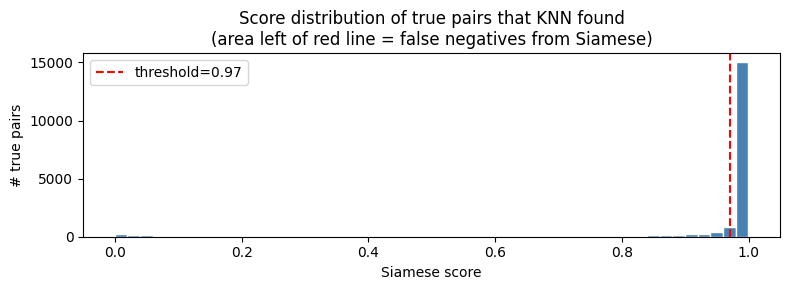

In [18]:
import matplotlib.pyplot as plt

# 1. Build a set of all true-positive pairs among the val items
#    (only items that have a label, i.e. duplicates; noise items are skipped)
val_id_to_idx = {item_id: idx for idx, item_id in enumerate(val_ids)}
label_to_items = {}
for item_id, lbl in val_labels.items():
    label_to_items.setdefault(lbl, []).append(item_id)

true_pairs = set()
for members in label_to_items.values():
    ids = [m for m in members if m in val_id_to_idx]
    for a in range(len(ids)):
        for b in range(a + 1, len(ids)):
            ia, ib = val_id_to_idx[ids[a]], val_id_to_idx[ids[b]]
            if ia > ib:
                ia, ib = ib, ia
            true_pairs.add((ia, ib))

n_true = len(true_pairs)
print(f'Total true-positive pairs in val set : {n_true:,}')

# 2. Which true pairs appear in the KNN candidates?
knn_set = set(zip(all_i.tolist(), all_j.tolist()))
found_in_knn = true_pairs & knn_set
n_knn_found  = len(found_in_knn)
knn_recall   = n_knn_found / n_true if n_true else 0
print(f'True pairs found by KNN              : {n_knn_found:,}  ({knn_recall:.1%})')

# 3. Of those found by KNN, how many score ≥ BEST_THRESHOLD?
score_lookup = {(int(i), int(j)): float(s)
                for i, j, s in zip(all_i, all_j, siamese_scores_val)}
scores_of_found = [score_lookup[(ia, ib)] for (ia, ib) in found_in_knn]
siamese_hits     = sum(s >= BEST_THRESHOLD for s in scores_of_found)
siamese_recall_given_knn = siamese_hits / n_knn_found if n_knn_found else 0
print(f'Of KNN-found pairs, Siamese keeps     : {siamese_hits:,}  ({siamese_recall_given_knn:.1%})  [threshold={BEST_THRESHOLD}]')

# 4. Overall recall decomposition
print(f'\nRecall decomposition:')
print(f'  Overall recall = KNN recall × Siamese|KNN recall')
print(f'  {knn_recall:.3f}  ×  {siamese_recall_given_knn:.3f}  =  {knn_recall * siamese_recall_given_knn:.3f}')

# 5. Verdict
print('\n' + '='*60)
if knn_recall < siamese_recall_given_knn:
    print('🔴 PRIMARY BOTTLENECK: KNN stage')
    print(f'   {1-knn_recall:.1%} of true pairs never even become candidates.')
    print('   Fixes: lower KNN_COSINE_THRESHOLD, increase TOP_K,')
    print('          or add a second KNN stream (image-only / text-only union).')
else:
    print('🔴 PRIMARY BOTTLENECK: Siamese stage')
    print(f'   {1-siamese_recall_given_knn:.1%} of KNN-found true pairs are rejected by the Siamese threshold.')
    print('   Fixes: retrain with harder negatives, lower BEST_THRESHOLD slightly,')
    print('          or use a softer final clustering (e.g. weighted edges).')
print('='*60)

# 6. Histogram of Siamese scores for the true pairs found by KNN
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(scores_of_found, bins=50, color='steelblue', edgecolor='white')
ax.axvline(BEST_THRESHOLD, color='red', linestyle='--', label=f'threshold={BEST_THRESHOLD}')
ax.set_xlabel('Siamese score')
ax.set_ylabel('# true pairs')
ax.set_title('Score distribution of true pairs that KNN found\n(area left of red line = false negatives from Siamese)')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Sanity check — print random clusters

Pick some predicted clusters at random (mix of multi-item and singleton) and display item titles + geo. Easy way to spot obvious mistakes.

  Connected components: 20,786 clusters from 30,000 items
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total clusters            :   20,786
  Singletons  (size == 1)   :   15,943  (76.7%)
  Multi-item  (size >= 2)   :    4,843  (23.3%)
  Largest cluster           :       22
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


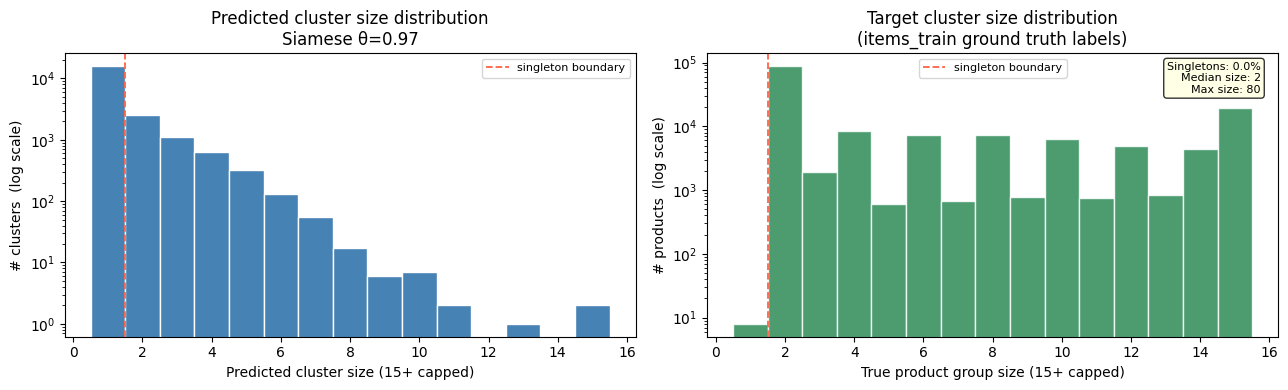


Target multi-item groups (from full train):  152,362
Predicted multi-item clusters (val subset):  4,843  (expected ~4,924 scaled to val size)

⚠️  If predicted >> expected → model generating too many fake clusters (high FP rate)
⚠️  If predicted << expected → model too conservative, missing duplicates (high FN rate)


In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# Re-cluster val set with best Siamese threshold for sanity check
mask_best = siamese_scores_val >= BEST_THRESHOLD
er_best, ec_best = all_i[mask_best], all_j[mask_best]
val_id2cluster = edges_to_clusters(er_best, ec_best, N, val_ids)

# Invert: cluster_id → [item_ids]
cluster2items = defaultdict(list)
for iid, cid in val_id2cluster.items():
    cluster2items[cid].append(iid)

multi_clusters = {cid: m for cid, m in cluster2items.items() if len(m) > 1}
sing_clusters  = {cid: m for cid, m in cluster2items.items() if len(m) == 1}

sizes_arr = np.array([len(v) for v in cluster2items.values()])
n_total      = len(sizes_arr)
n_singletons = int((sizes_arr == 1).sum())
n_multi      = int((sizes_arr > 1).sum())

print('━'*58)
print(f'  Total clusters            : {n_total:>8,}')
print(f'  Singletons  (size == 1)   : {n_singletons:>8,}  ({100*n_singletons/n_total:.1f}%)')
print(f'  Multi-item  (size >= 2)   : {n_multi:>8,}  ({100*n_multi/n_total:.1f}%)')
print(f'  Largest cluster           : {int(sizes_arr.max()):>8,}')
print('━'*58)

# ── Target cluster size distribution from items_train labels ──────────────────
label_sizes = df_train['label'].value_counts()
target_sizes = label_sizes.values  # how many items each true product has

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: predicted cluster size distribution (current run)
cap  = 15
bins = np.arange(0.5, cap + 1.5, 1)
ax1.hist(np.clip(sizes_arr, 1, cap), bins=bins, color='steelblue', edgecolor='white')
ax1.set_yscale('log')
ax1.set_xlabel('Predicted cluster size (15+ capped)')
ax1.set_ylabel('# clusters  (log scale)')
ax1.set_title(f'Predicted cluster size distribution\nSiamese θ={BEST_THRESHOLD}')
ax1.axvline(1.5, color='tomato', linestyle='--', linewidth=1.3, label='singleton boundary')
ax1.legend(fontsize=8)

# Right: TARGET cluster size distribution from ground-truth labels in items_train
ax2.hist(np.clip(target_sizes, 1, cap), bins=bins, color='seagreen', edgecolor='white', alpha=0.85)
ax2.set_yscale('log')
ax2.set_xlabel('True product group size (15+ capped)')
ax2.set_ylabel('# products  (log scale)')
ax2.set_title('Target cluster size distribution\n(items_train ground truth labels)')
ax2.axvline(1.5, color='tomato', linestyle='--', linewidth=1.3, label='singleton boundary')

# Overlay key stats
pct_single_target = 100 * (target_sizes == 1).sum() / len(target_sizes)
ax2.text(0.97, 0.97, f'Singletons: {pct_single_target:.1f}%\nMedian size: {int(np.median(target_sizes))}\nMax size: {int(target_sizes.max())}',
         transform=ax2.transAxes, ha='right', va='top', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Compare predicted vs target multi-item cluster counts ─────────────────────
n_target_multi = int((target_sizes > 1).sum())
print(f'\nTarget multi-item groups (from full train):  {n_target_multi:,}')
print(f'Predicted multi-item clusters (val subset):  {n_multi:,}  (expected ~{int(n_target_multi * len(val_ids) / len(df_train)):,} scaled to val size)')
print(f'\n⚠️  If predicted >> expected → model generating too many fake clusters (high FP rate)')
print(f'⚠️  If predicted << expected → model too conservative, missing duplicates (high FN rate)')


show_cluster() and print_cluster() defined.
--- 10 random MULTI-ITEM predicted clusters ---


/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_2130/1516088813.py:62: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


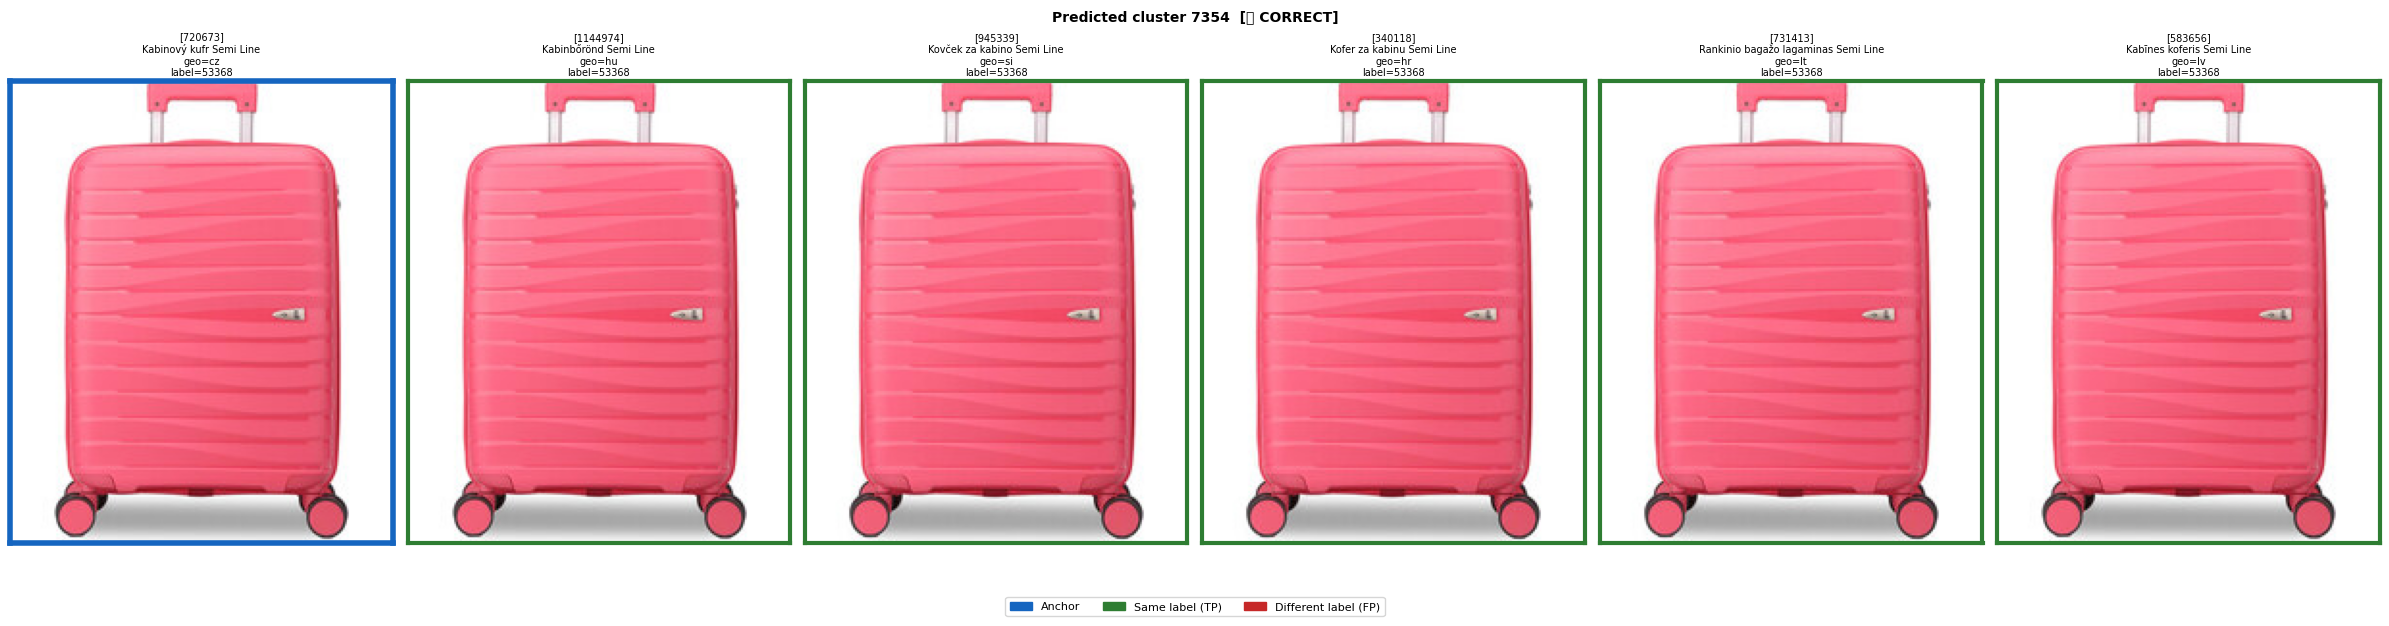

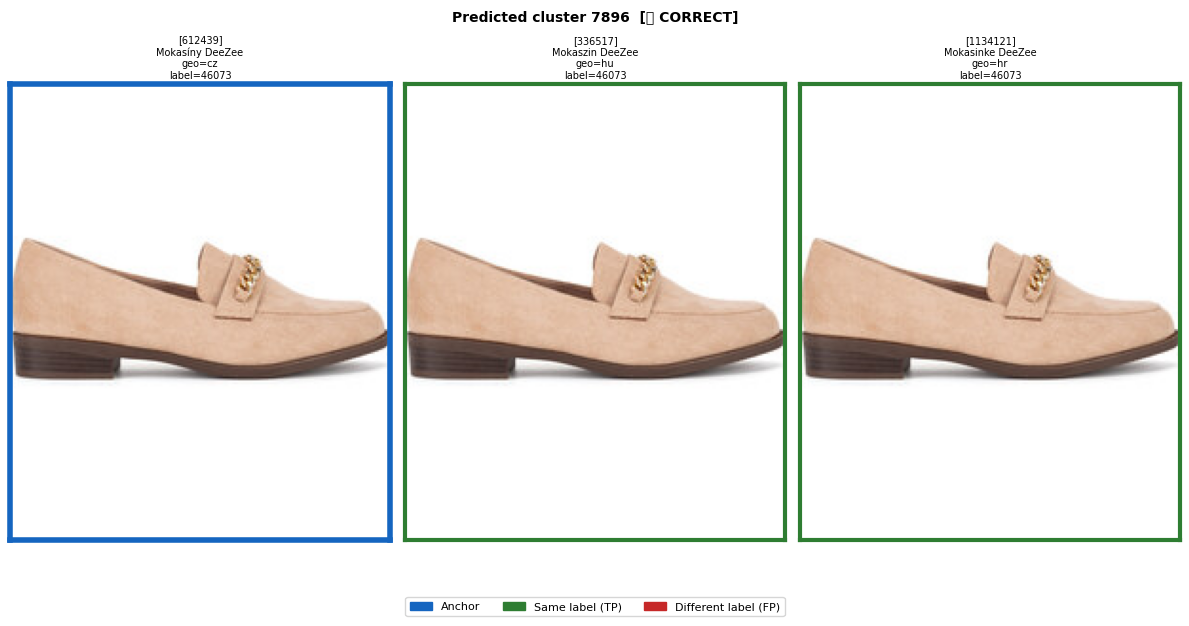

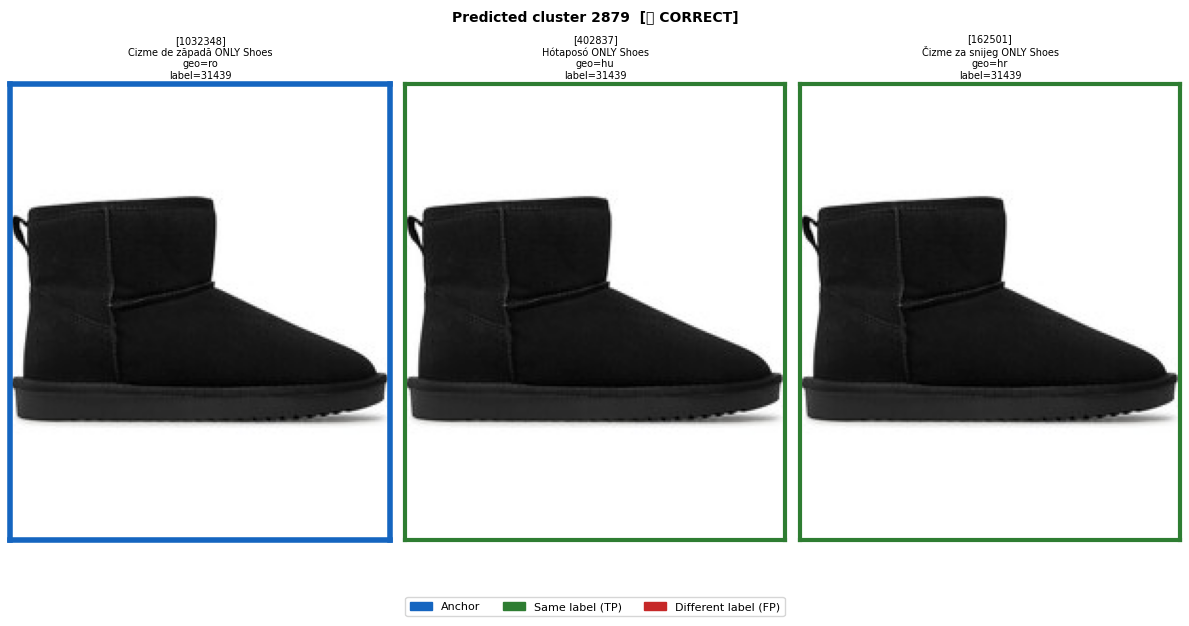

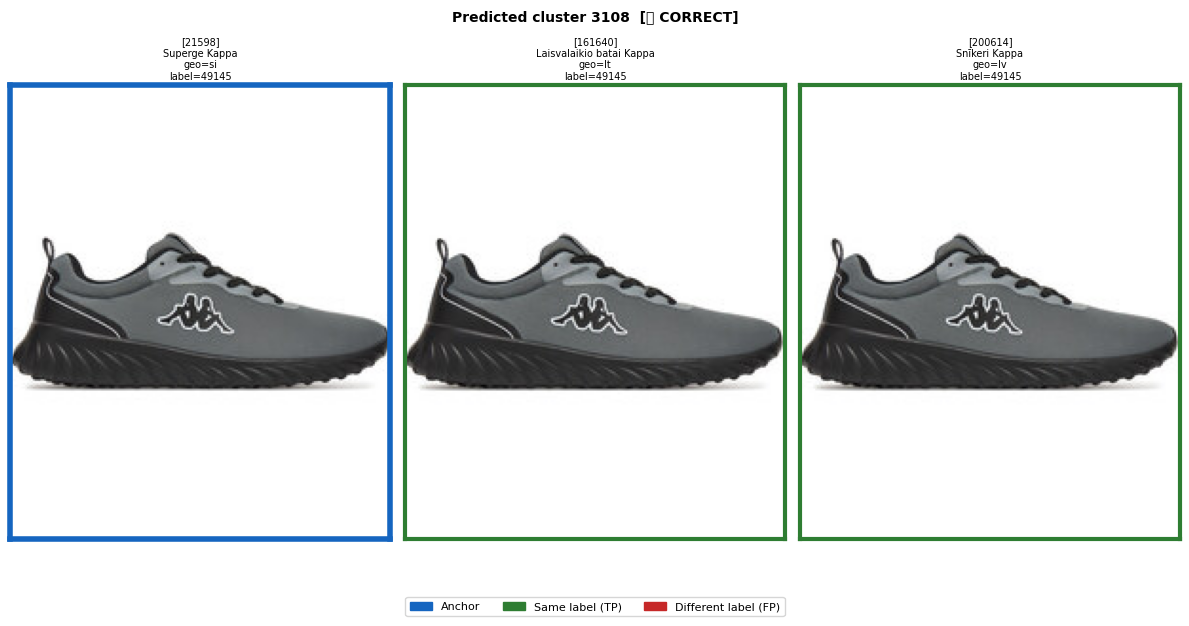

/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_2130/1516088813.py:62: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


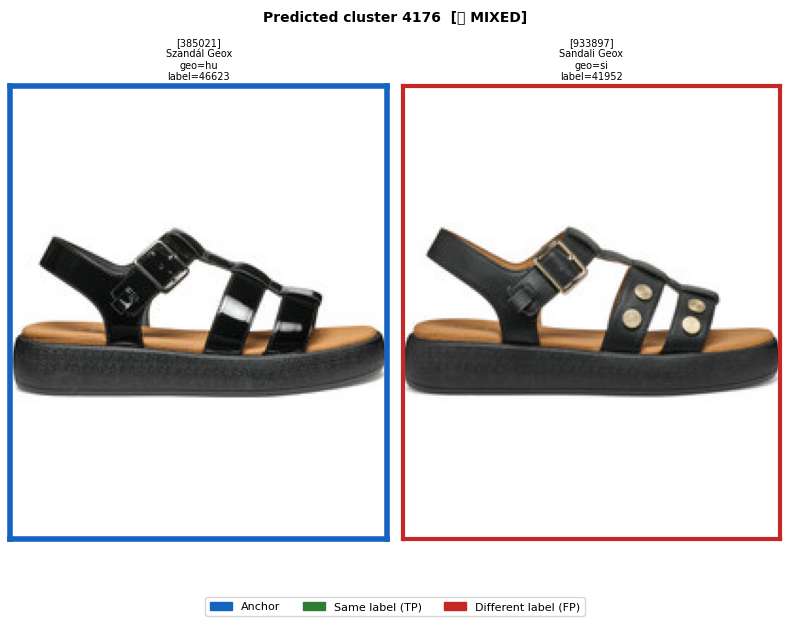

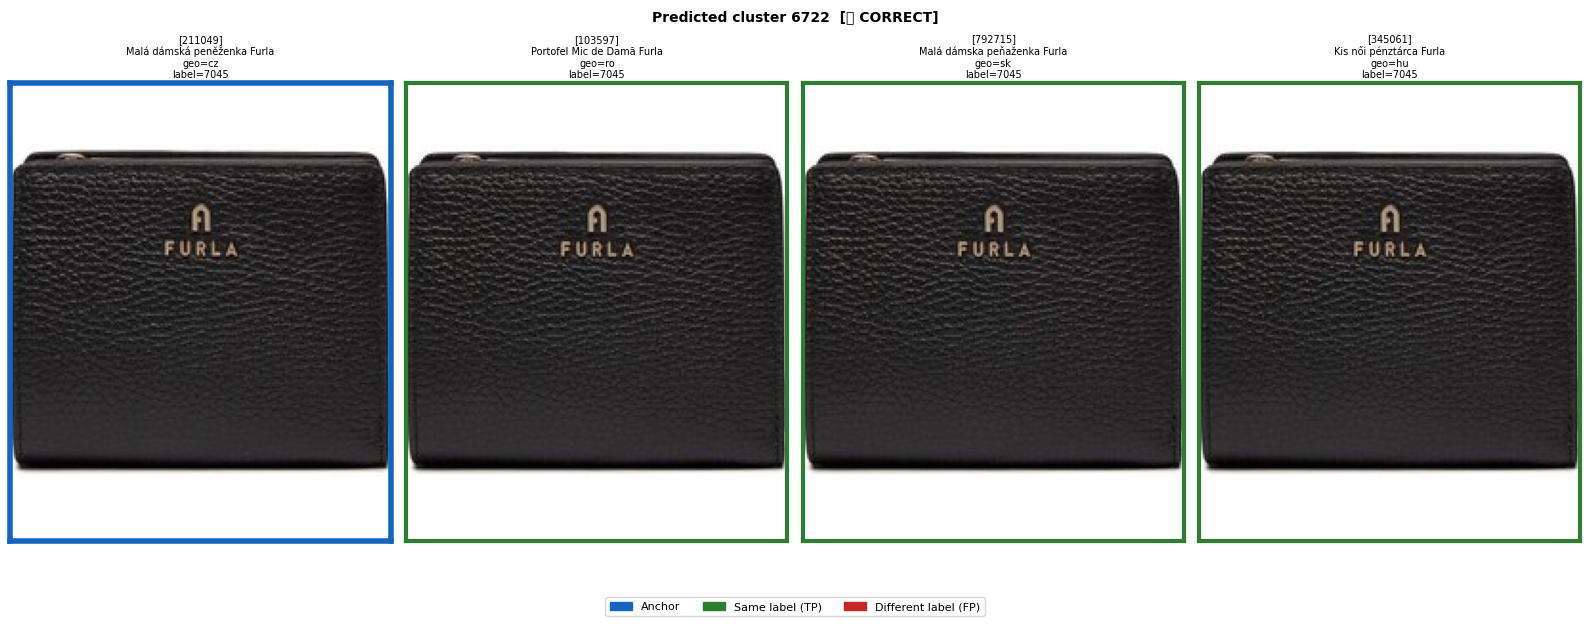

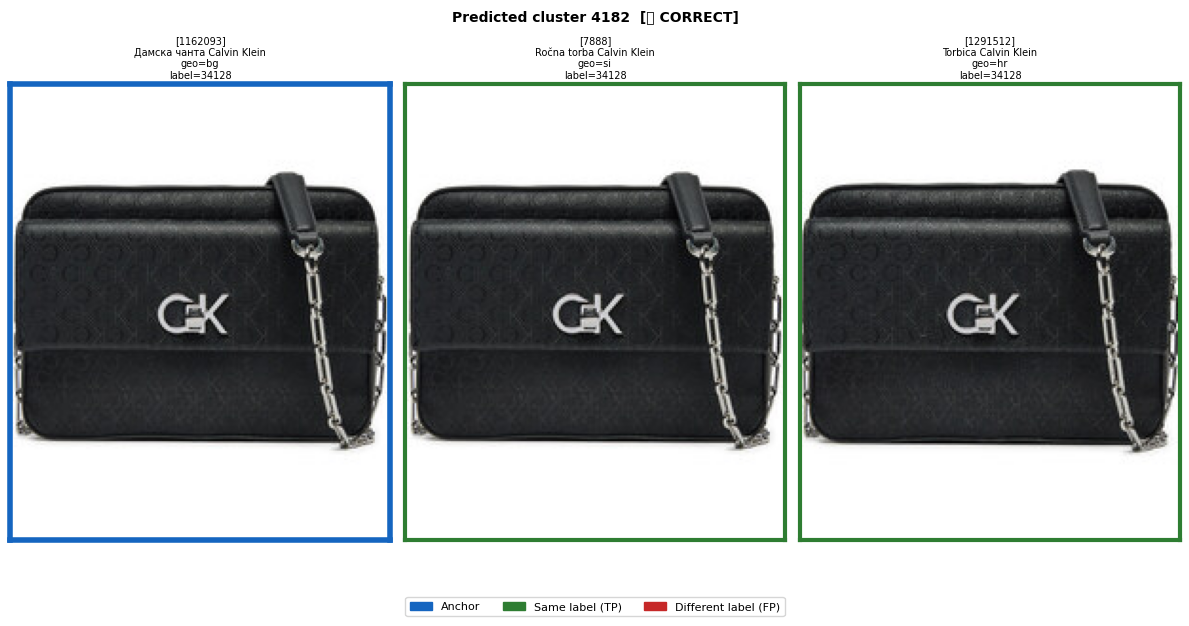

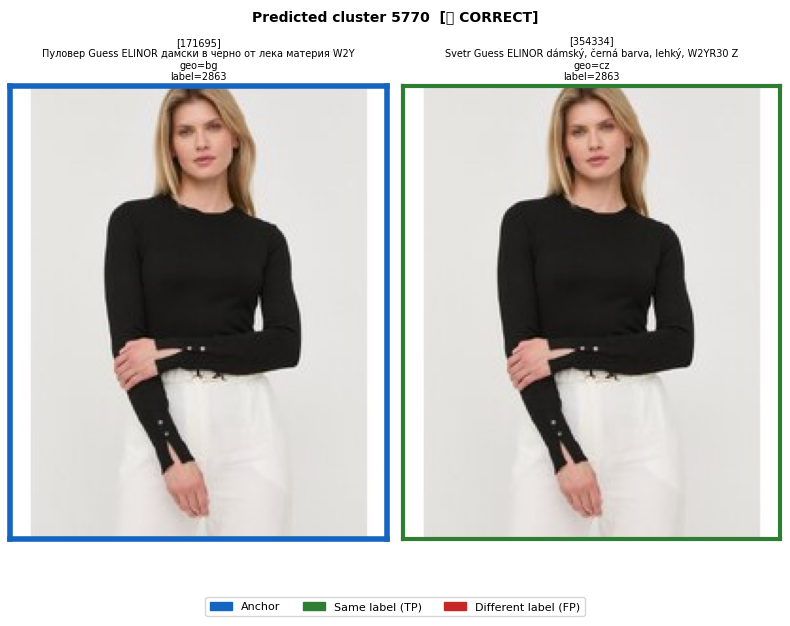

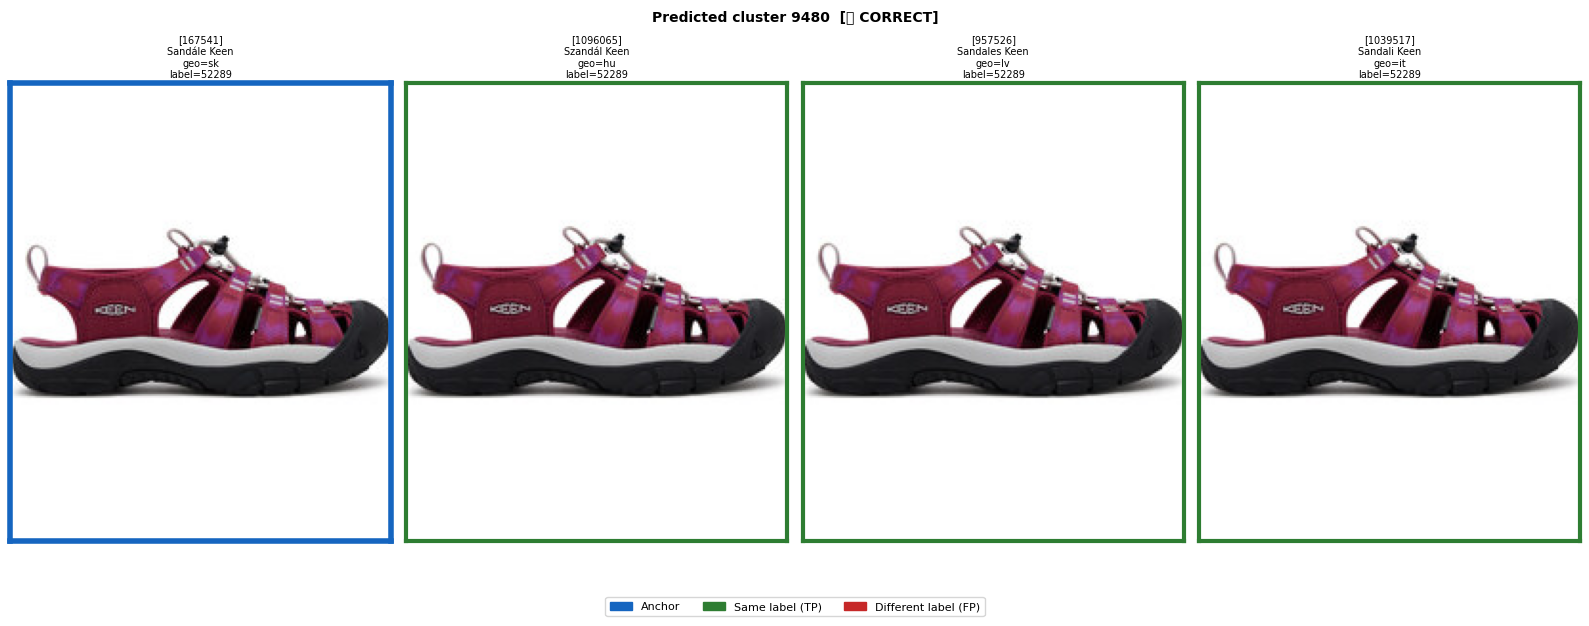

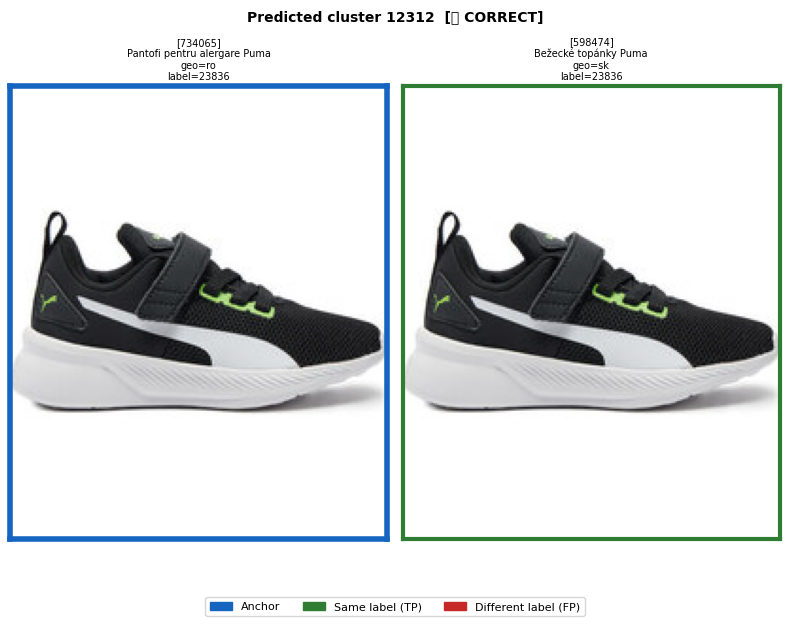

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

IMAGES_DIR = '/Users/matouskovar/FIT/images'  # DO NOT LIST — open per-item only

# Meta lookup (title, geo) from original df_train rows for val items
_val_rows = df_train[df_train['itemId'].isin(val_ids_set)].set_index('itemId')
val_meta  = _val_rows[['title', 'geo']].to_dict('index')
for iid, lbl in val_labels.items():
    val_meta.setdefault(iid, {})['label'] = lbl

def _load_img(item_id):
    path = os.path.join(IMAGES_DIR, f'{item_id}.jpg')
    try:
        return Image.open(path).convert('RGB')
    except Exception:
        return None

def show_cluster(cid, members, id2label=val_labels, text_chars=55):
    true_labels = [str(id2label.get(iid, '?')) for iid in members]
    is_correct  = len(set(true_labels)) == 1
    flag = '✅ CORRECT' if is_correct else '❌ MIXED'

    n_cols = len(members)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 6))
    if n_cols == 1:
        axes = [axes]

    ref_label = true_labels[0]
    for ax, iid, true_lbl in zip(axes, members, true_labels):
        img = _load_img(iid)
        if img:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'no image', ha='center', va='center',
                    fontsize=9, transform=ax.transAxes)
            ax.set_facecolor('#eeeeee')

        if iid == members[0]:
            color, lw = '#1565C0', 4
        elif true_lbl == ref_label:
            color, lw = '#2e7d32', 3
        else:
            color, lw = '#c62828', 3
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(lw)

        meta  = val_meta.get(iid, {})
        title = str(meta.get('title', 'N/A'))[:text_chars]
        geo   = meta.get('geo', '?')
        ax.set_title(f'[{iid}]\n{title}\ngeo={geo}\nlabel={true_lbl}', fontsize=7, pad=4)
        ax.set_xticks([]); ax.set_yticks([])

    patches = [
        mpatches.Patch(color='#1565C0', label='Anchor'),
        mpatches.Patch(color='#2e7d32', label='Same label (TP)'),
        mpatches.Patch(color='#c62828', label='Different label (FP)'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(f'Predicted cluster {cid}  [{flag}]', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

def print_cluster(cid, members, id2label=val_labels):
    true_labels = [str(id2label.get(iid, '?')) for iid in members]
    flag = '✅ CORRECT' if len(set(true_labels)) == 1 else '❌ MIXED'
    print(f'\n{"─"*70}\nPredicted cluster {cid}  ({len(members)} items)  [{flag}]\n{"─"*70}')
    for iid in members:
        meta  = val_meta.get(iid, {})
        print(f'  [{iid}] geo={meta.get("geo","?"):3s}  label={str(id2label.get(iid,"?")):>8s}  '
              f'"{str(meta.get("title","N/A"))[:80]}"')

print('show_cluster() and print_cluster() defined.')
print('--- 10 random MULTI-ITEM predicted clusters ---')
sample_multi = random.sample(list(multi_clusters.items()), min(10, len(multi_clusters)))
for cid, members in sample_multi:
    show_cluster(cid, members)


Multi-item clusters: 4,843
  Correct (all same label): 4,650  (96.0%)
  Bad    (mixed labels):    193  (4.0%)

--- 5 examples of BAD merges (FP — different true labels grouped together) ---


/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_2130/1516088813.py:62: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


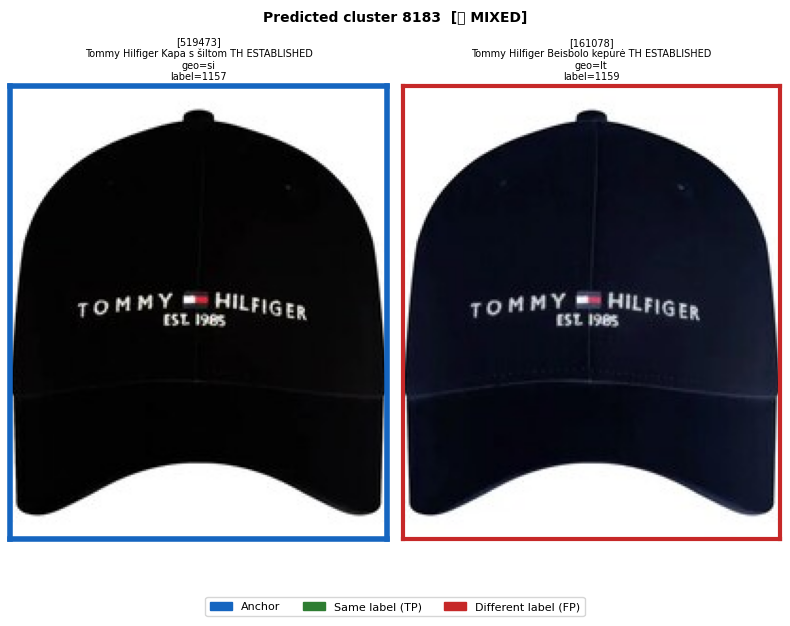

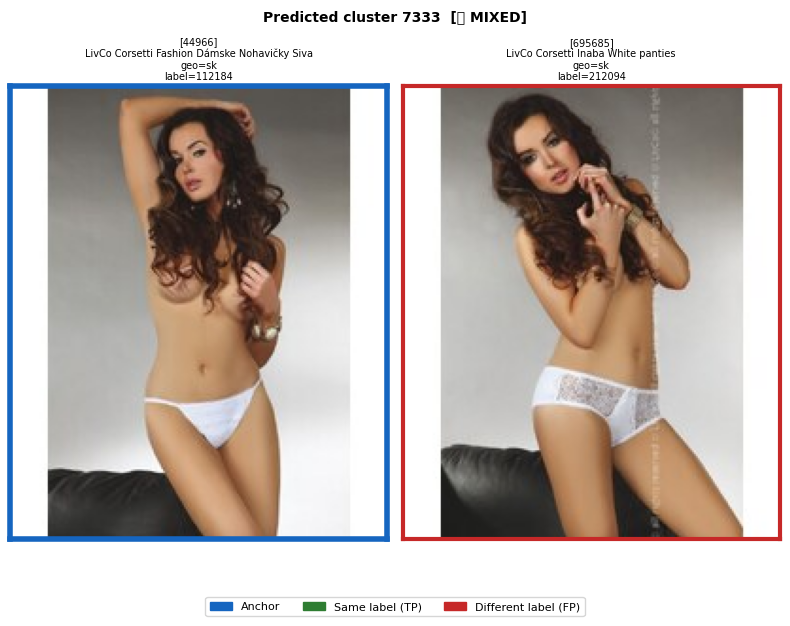

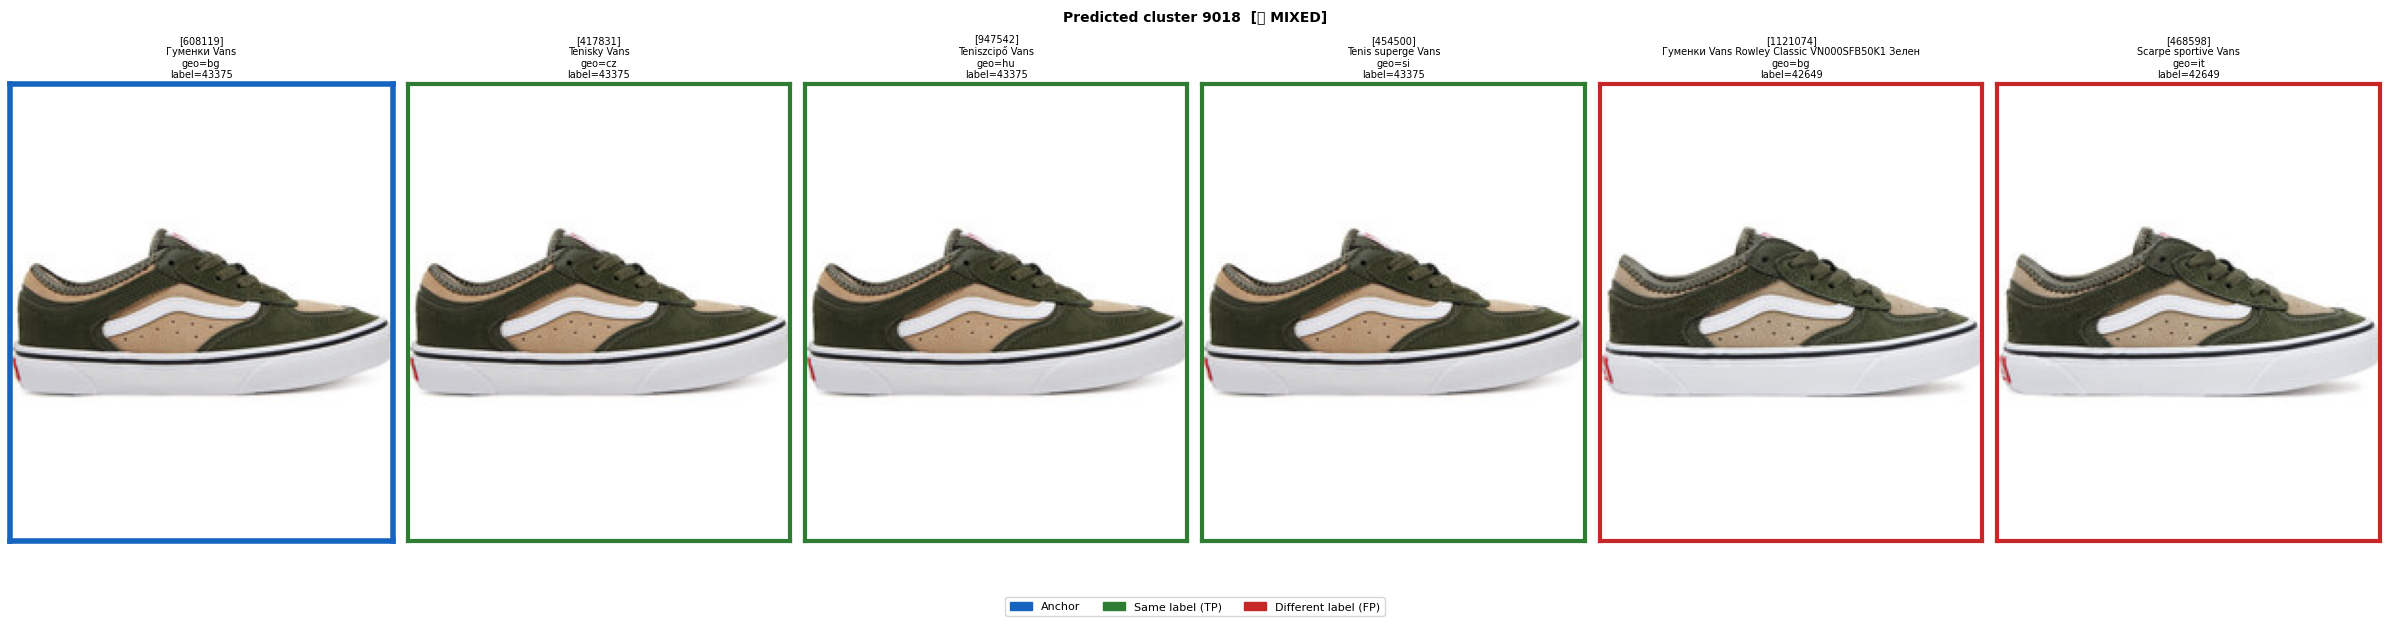

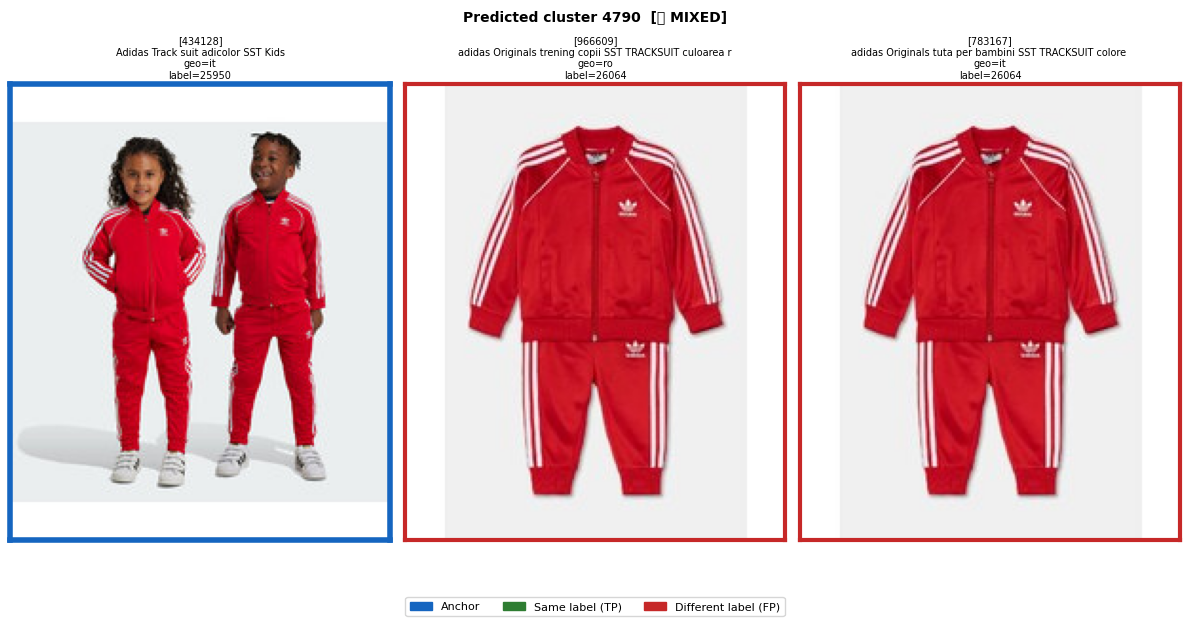

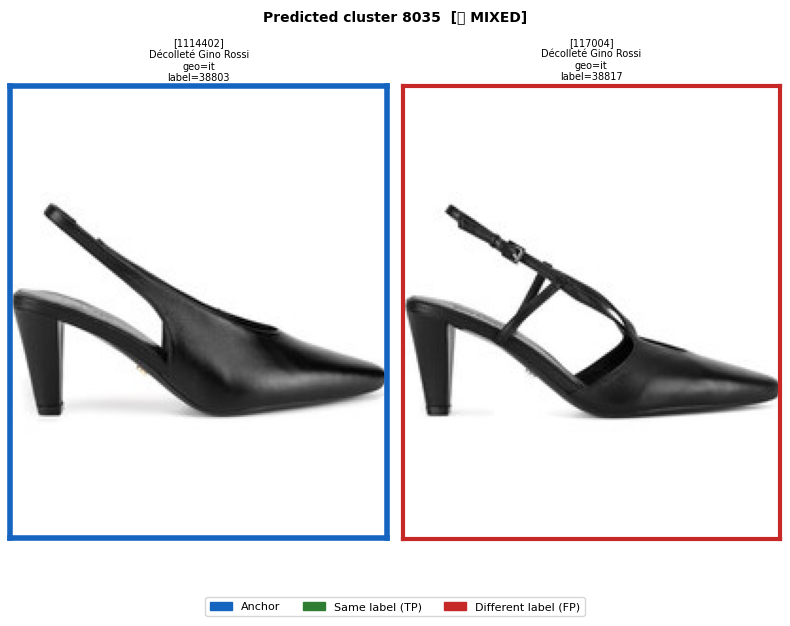

In [21]:
bad_clusters = {
    cid: members for cid, members in multi_clusters.items()
    if len(set(val_labels.get(iid, '?') for iid in members)) > 1
}
good_clusters = {
    cid: members for cid, members in multi_clusters.items()
    if len(set(val_labels.get(iid, '?') for iid in members)) == 1
}

print(f'Multi-item clusters: {len(multi_clusters):,}')
print(f'  Correct (all same label): {len(good_clusters):,}  ({100*len(good_clusters)/max(1,len(multi_clusters)):.1f}%)')
print(f'  Bad    (mixed labels):    {len(bad_clusters):,}  ({100*len(bad_clusters)/max(1,len(multi_clusters)):.1f}%)')

print('\n--- 5 examples of BAD merges (FP — different true labels grouped together) ---')
for cid, members in random.sample(list(bad_clusters.items()), min(5, len(bad_clusters))):
    show_cluster(cid, members)


True-positive groups split into multiple predicted clusters: 1,612

--- 5 examples of SPLIT true groups (FN — same product, different predicted clusters) ---


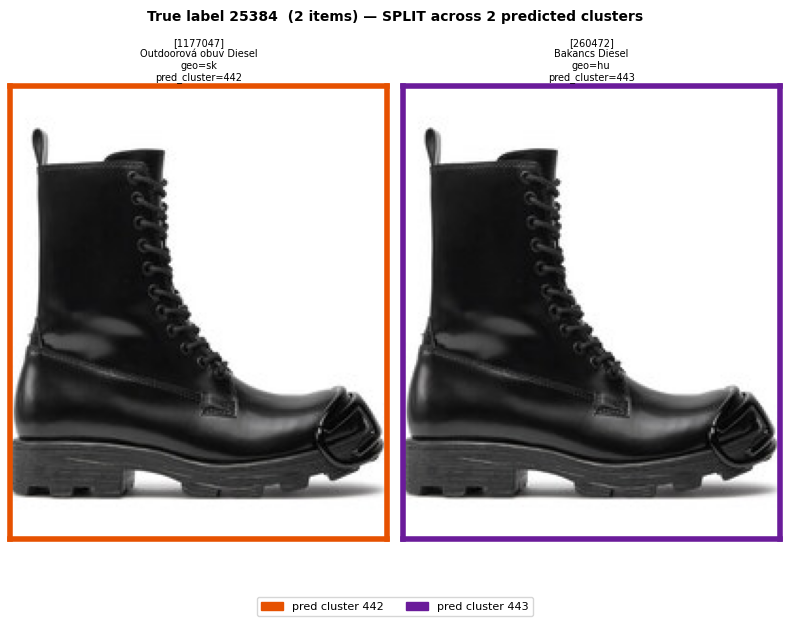

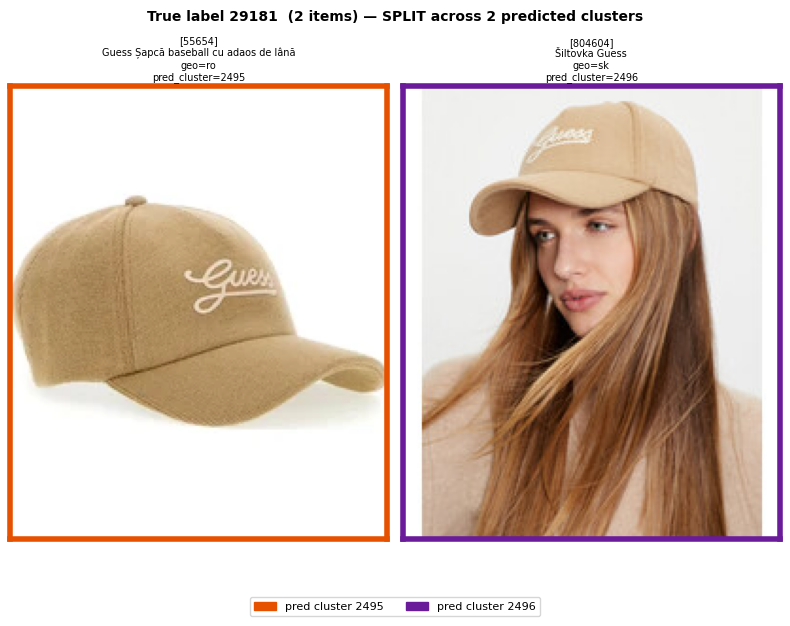

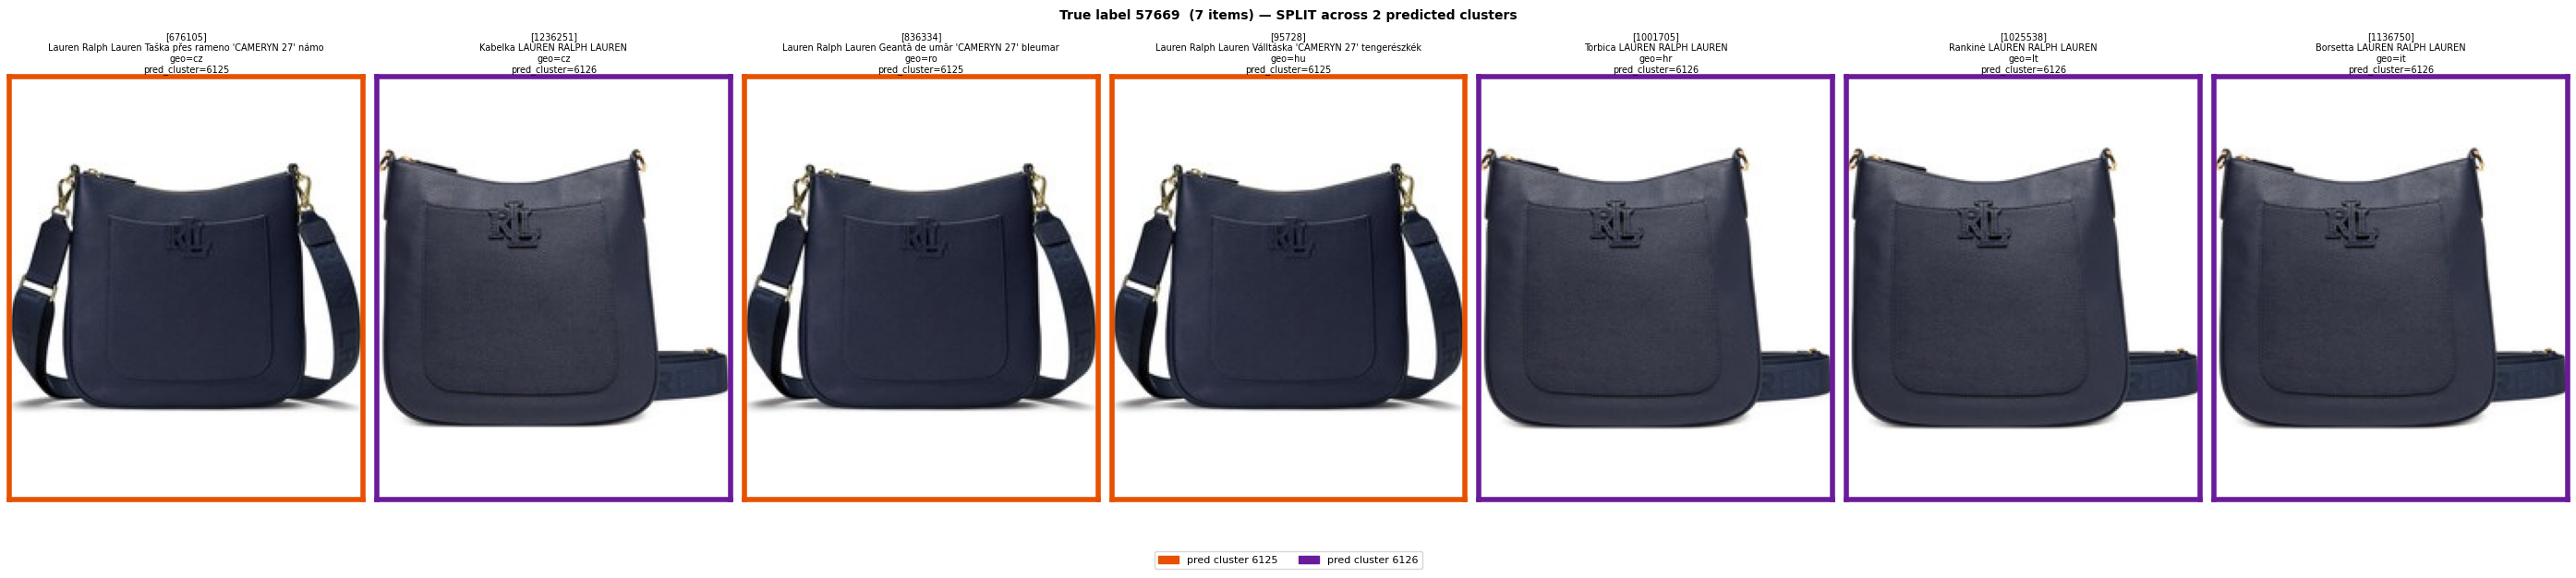

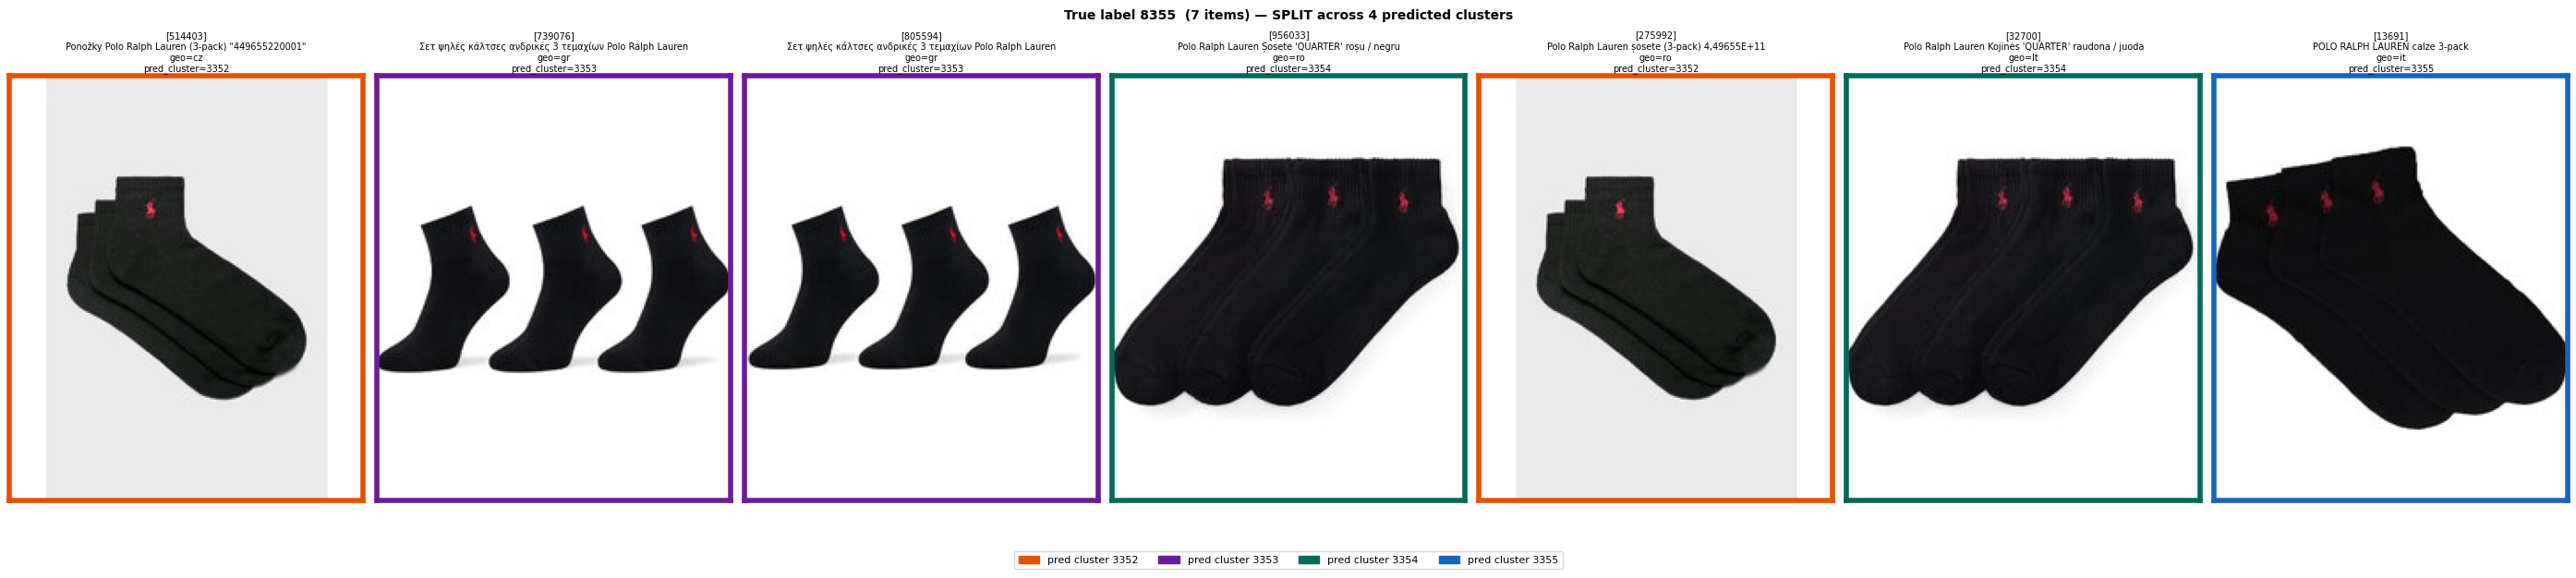

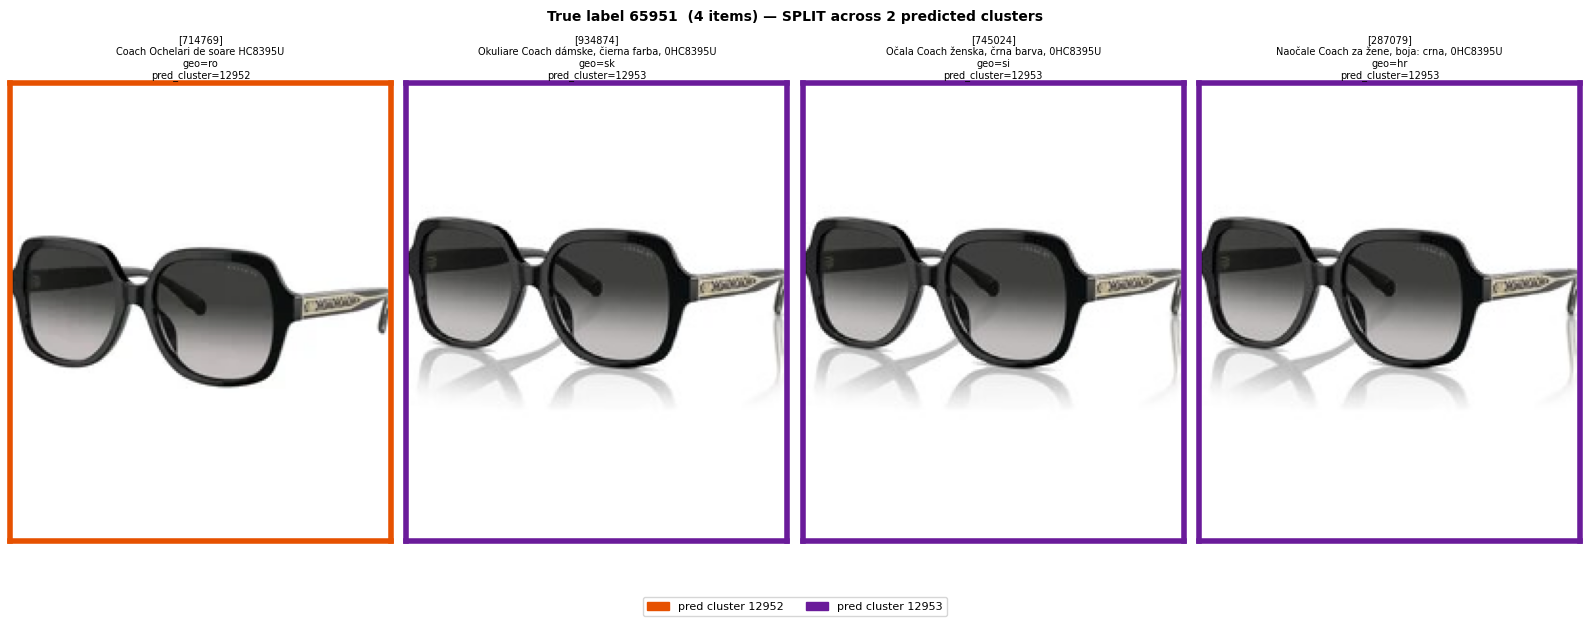

In [22]:
true_groups_val = defaultdict(list)
for iid in val_ids:
    true_groups_val[val_labels.get(iid)].append(iid)

split_true_labels = [
    (lbl, members) for lbl, members in true_groups_val.items()
    if len(members) >= 2
    and len(set(val_id2cluster[iid] for iid in members)) > 1
]

print(f'True-positive groups split into multiple predicted clusters: {len(split_true_labels):,}')
print('\n--- 5 examples of SPLIT true groups (FN — same product, different predicted clusters) ---')

for lbl, members in random.sample(split_true_labels, min(5, len(split_true_labels))):
    # Show all items of the true group, colour-coded by their predicted cluster id
    pred_clusters_for_group = sorted(set(val_id2cluster[iid] for iid in members))
    n_cols = len(members)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 6))
    if n_cols == 1:
        axes = [axes]

    # Assign a distinct colour per predicted cluster
    cluster_colors = ['#e65100', '#6a1b9a', '#00695c', '#1565C0', '#558b2f']
    pred_cid_to_color = {cid: cluster_colors[i % len(cluster_colors)]
                         for i, cid in enumerate(pred_clusters_for_group)}

    for ax, iid in zip(axes, members):
        img = _load_img(iid)
        if img:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'no image', ha='center', va='center',
                    fontsize=9, transform=ax.transAxes)
            ax.set_facecolor('#eeeeee')

        pred_c = val_id2cluster[iid]
        color  = pred_cid_to_color[pred_c]
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(4)

        meta  = val_meta.get(iid, {})
        title = str(meta.get('title', 'N/A'))[:55]
        geo   = meta.get('geo', '?')
        ax.set_title(f'[{iid}]\n{title}\ngeo={geo}\npred_cluster={pred_c}', fontsize=7, pad=4)
        ax.set_xticks([])
        ax.set_yticks([])

    patches = [mpatches.Patch(color=pred_cid_to_color[c], label=f'pred cluster {c}')
               for c in pred_clusters_for_group]
    fig.legend(handles=patches, loc='lower center', ncol=len(patches), fontsize=8,
               bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(f'True label {lbl}  ({len(members)} items) — SPLIT across {len(pred_clusters_for_group)} predicted clusters',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 8. Apply to `items_phase_2.csv` → submission

If phase 2 data exists, cluster it and write submission.

In [23]:
PHASE2_PATH = f'{DATA_DIR}/items_phase_2.csv'

if not os.path.exists(PHASE2_PATH):
    print(f'⚠️  {PHASE2_PATH} not found — skipping submission generation.')
else:
    print('Loading items_phase_2.csv...')
    df_p2 = pd.read_csv(PHASE2_PATH)
    df_p2['itemId'] = df_p2['itemId'].astype(str)
    print(f'  {len(df_p2):,} items')

    # Preprocess through pipeline → price_scaled, departmentIds, colorTagIdsString
    df_p2_proc = preprocess_df(df_p2, pipeline)

    # Keep only items that have embeddings
    have_emb = set(clip_emb_dict.keys()) & set(text_emb_dict.keys())
    df_p2_proc_valid = df_p2_proc[df_p2_proc['itemId'].isin(have_emb)].reset_index(drop=True)
    p2_ids    = df_p2_proc_valid['itemId'].tolist()
    missing   = len(df_p2) - len(p2_ids)
    print(f'  Items with embeddings: {len(p2_ids):,}  (missing: {missing:,})')

    # Build LightweightItemDataset for phase-2
    p2_item_dataset = LightweightItemDataset(
        df_p2_proc_valid, vocab_manager,
        image_embeddings_dict=clip_emb_dict,
        text_embeddings_dict=text_emb_dict
    )
    print(f'  Item dataset: {len(p2_item_dataset)} items')

    # ── Build joint embedding matrix (image+text) for cosine KNN ─────────────
    print('Building phase-2 embedding matrix...')
    p2_mat = build_embedding_matrix(p2_ids, clip_emb_dict, text_emb_dict)
    print(f'  Shape: {p2_mat.shape}')

    # ── Cosine KNN (wide net) ─────────────────────────────────────────────────
    N2 = p2_mat.shape[0]
    p2_mat_dev = p2_mat.to(device)
    p2_i, p2_j = [], []
    p2_nbr = defaultdict(set)

    print(f'Running cosine KNN (threshold={KNN_COSINE_THRESHOLD}, K={TOP_K})...')
    for start in range(0, N2, BLOCK):
        end   = min(start + BLOCK, N2)
        block = p2_mat_dev[start:end]
        sims  = torch.mm(block, p2_mat_dev.T)
        for bi in range(end - start):
            sims[bi, start + bi] = -2.0
        vals, idxs = torch.topk(sims, k=TOP_K, dim=1)
        for bi in range(end - start):
            gi = start + bi
            for ki in range(TOP_K):
                gj  = idxs[bi, ki].item()
                sim = vals[bi, ki].item()
                if sim < KNN_COSINE_THRESHOLD:
                    continue
                p2_nbr[gi].add(gj)
                if gj > gi:
                    p2_i.append(gi); p2_j.append(gj)
        if (start // BLOCK) % 20 == 0:
            print(f'  {start:>6}/{N2}', end='\r')

    p2_i = np.array(p2_i, dtype=np.int32)
    p2_j = np.array(p2_j, dtype=np.int32)

    if MUTUAL:
        keep = [k for k, (gi, gj) in enumerate(zip(p2_i, p2_j))
                if gj in p2_nbr[gi] and gi in p2_nbr[gj]]
        p2_i, p2_j = p2_i[keep], p2_j[keep]
    print(f'  Candidate edges after mutual filter: {len(p2_i):,}')

    # ── Siamese re-scoring ────────────────────────────────────────────────────
    print('Siamese re-scoring...')
    p2_siamese_scores = score_edges_siamese(
        p2_i, p2_j, p2_item_dataset, siamese_model, device, batch_size=1024)

    # Filter by best Siamese threshold found on val
    mask_p2 = p2_siamese_scores >= BEST_THRESHOLD
    er_p2 = p2_i[mask_p2]
    ec_p2 = p2_j[mask_p2]
    print(f'  Edges after Siamese filter (θ={BEST_THRESHOLD}): {mask_p2.sum():,}')

    # ── Connected components → clusters ───────────────────────────────────────
    p2_id2cluster = edges_to_clusters(er_p2, ec_p2, N2, p2_ids)

    # Items with no embeddings get their own singleton cluster
    next_id = max(p2_id2cluster.values()) + 1 if p2_id2cluster else 0
    for iid in df_p2['itemId']:
        if iid not in p2_id2cluster:
            p2_id2cluster[iid] = next_id; next_id += 1

    # Invert
    p2_cluster2items = defaultdict(list)
    for iid, cid in p2_id2cluster.items():
        p2_cluster2items[cid].append(iid)

    # Enforce ≤ 100 items per line
    MAX_PER_LINE = 100
    output_lines = []
    for members in p2_cluster2items.values():
        for chunk_start in range(0, len(members), MAX_PER_LINE):
            output_lines.append(','.join(members[chunk_start:chunk_start + MAX_PER_LINE]))


    out_path = f'{NOTEBOOK_DIR}/../artifacts/submissions/submission_phase2_final.csv'
    with open(out_path, 'w') as f:
        f.write('\n'.join(output_lines))

    multi_p2 = sum(1 for m in p2_cluster2items.values() if len(m) > 1)
    print(f'\n✅ Submission written → {out_path}')
    print(f'   Lines: {len(output_lines):,}  |  Multi-item clusters: {multi_p2:,}')
    print(f'   All items covered: {len(p2_id2cluster) == len(df_p2)}')

Loading items_phase_2.csv...
  197,837 items
  Items with embeddings: 0  (missing: 197,837)
  Item dataset: 0 items
Building phase-2 embedding matrix...


RuntimeError: stack expects a non-empty TensorList

## 9. Quick phase-1 items sanity check (same pipeline)

Phase-1 items share the same embedding space. Let's also sanity-check a few clusters on them for completeness (no ground truth, just visual check).

In [ ]:
# Quick check: what fraction of phase-1 items have embeddings?
df_p1 = pd.read_csv(f'{DATA_DIR}/items_phase_2.csv')
df_p1['itemId'] = df_p1['itemId'].astype(str)
have_emb = set(clip_emb_dict.keys()) & set(text_emb_dict.keys())
p1_with_emb = df_p1['itemId'].isin(have_emb).sum()
print(f'Phase-1 items: {len(df_p1):,}')
print(f'  With embeddings: {p1_with_emb:,}  ({100*p1_with_emb/len(df_p1):.1f}%)')

Phase-1 items: 199,835
  With embeddings: 199,835  (100.0%)


## 10. Random cluster sanity check on the submission file

Picks one random **multi-item** cluster from the submission file (`submission_phase2.csv`)
and shows all its items with images + title + geo. **Re-run the cell** to draw a
different cluster.

No ground-truth labels for the unlabeled phase items, so this is a pure visual
sanity check — items in the same cluster should *look like the same product*
across geos / minor photo differences.

Submission lines       : 37,788
Multi-item clusters    : 34,331
Singletons             : 3,457

Drew cluster of 2 items


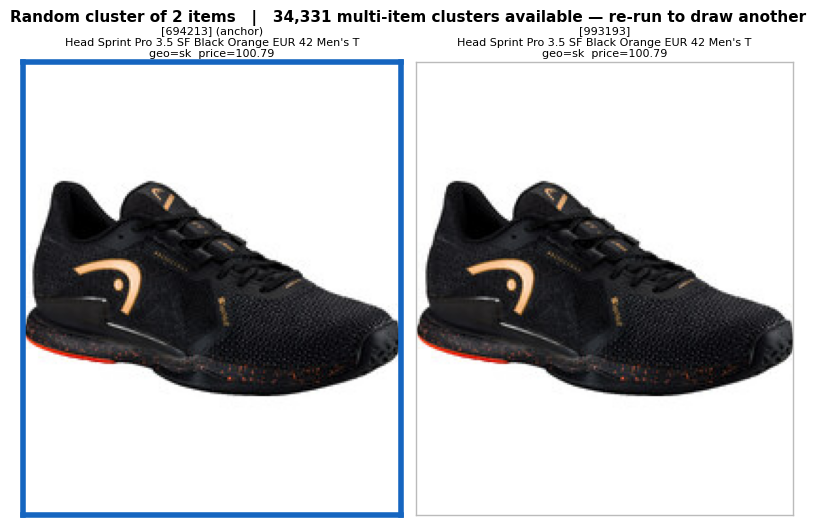

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image as _PILImage

SUBMISSION_PATH = f'{NOTEBOOK_DIR}/../artifacts/submissions/submission_phase2_final.csv'
IMAGES_DIR      = '/Users/matouskovar/FIT/images'

# Build metadata lookup (title, geo) from items_phase_1
df_p1 = pd.read_csv(f'{DATA_DIR}/items_phase_1.csv')
df_p1['itemId'] = df_p1['itemId'].astype(str)
p1_meta = df_p1.set_index('itemId')[['title','geo','price']].to_dict('index')

# Read submission, keep only multi-item lines
with open(SUBMISSION_PATH) as f:
    submission_groups = [line.strip().split(',') for line in f if line.strip()]
multi_groups = [g for g in submission_groups if len(g) > 1]

print(f'Submission lines       : {len(submission_groups):,}')
print(f'Multi-item clusters    : {len(multi_groups):,}')
print(f'Singletons             : {len(submission_groups) - len(multi_groups):,}')

if not multi_groups:
    print('No multi-item clusters in the submission — nothing to show.')
else:
    # Fresh draw each cell run
    members = random.choice(multi_groups)
    n = len(members)
    print(f'\nDrew cluster of {n} items')

    fig, axes = plt.subplots(1, n, figsize=(min(4 * n, 22), 5.5))
    if n == 1:
        axes = [axes]
    for ax, iid in zip(axes, members):
        try:
            ax.imshow(_PILImage.open(f'{IMAGES_DIR}/{iid}.jpg').convert('RGB'))
        except Exception:
            ax.text(0.5, 0.5, 'no image', ha='center', va='center', transform=ax.transAxes)
            ax.set_facecolor('#eeeeee')

        # Anchor (first item) gets a blue border
        is_anchor = (iid == members[0])
        for sp in ax.spines.values():
            sp.set_edgecolor('#1565C0' if is_anchor else '#bbbbbb')
            sp.set_linewidth(4 if is_anchor else 1)

        meta  = p1_meta.get(iid, {})
        title = str(meta.get('title', ''))[:50]
        geo   = meta.get('geo', '?')
        price = meta.get('price', '?')
        marker = ' (anchor)' if is_anchor else ''
        ax.set_title(f'[{iid}]{marker}\n{title}\ngeo={geo}  price={price}',
                     fontsize=8, pad=4)
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(f'Random cluster of {n} items   |   {len(multi_groups):,} multi-item clusters available — re-run to draw another',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()